In [1]:
import pymc as pm; import arviz as az; import sys; import numpy as np; import pickle
import nutpie; import pytensor.tensor as pt; import matplotlib.pyplot as plt
sys.path.append(r'C:\Users\awast\OneDrive\Desktop\MKM')
from _CO_Oxidation.common import kb_eV, T, kb_J, h, F, N_A
from _CO_Oxidation import wrapper_base as wp
from _CO_Oxidation.wrapper_base import plot_posteriors, plot_model_fits, plot_coverages, plot_drc

C_KOH_list = np.array([0.25, 0.5, 1]) # in M 
P_CO_list = 0.01*np.array([0.1, 1, 10, 100]) # in atm 
experiments_data = pickle.load(open('import_Ag50Pd50_base_replicates.pkl', 'rb'))
wp.process_experimental_data(experiments_data, C_KOH_list, P_CO_list)
E_in = wp.E_in; P_CO_in = wp.P_CO_in; C_KOH_in = wp.C_KOH_in

def fit_and_evaluate(model, draws=1000, tune=2000, chains=4, cores=4, init_mean=None, target_accept=0.9):
    compiled_model = nutpie.compile_pymc_model(model)
    trace = nutpie.sample(compiled_model, draws=draws, tune=tune, chains=chains, cores=cores, init_mean=init_mean, target_accept=target_accept)
    pm.compute_log_likelihood(trace, progressbar=False, model=model)
    loo = az.loo(trace, pointwise=True)
    print(loo); az.plot_khat(loo); plt.title("Pareto k diagnostic"); plt.show()
    trace = wp.add_post_sampling_observables(trace)
    return trace, loo

def observables(log_rate):
    pm.Deterministic('log_rate', log_rate)
    rate_model = pt.exp(log_rate)
    sigma_rel = pm.Gamma('sigma_rel', alpha=2, beta=20)
    sigma_base = pm.HalfNormal('sigma_base', sigma=1e-2)
    exponent =  pm.HalfNormal('exponent', sigma=1)
    sigma_model = pt.sqrt(sigma_base**2 + (sigma_rel**2)*(rate_model ** exponent))
    # sigma_total = pt.sqrt(wp.rate_SD_obs**2 + sigma_model**2)
    rate = pm.StudentT('rate', nu=4, mu=rate_model, sigma=sigma_model, observed=wp.rate_obs_matrix)
    return rate

Ag_comp = 0.5

# LH 

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.40,7
,3000,0,0.40,15
,3000,0,0.42,15
,3000,0,0.41,15


Computed from 4000 posterior samples and 1476 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -1311.47    52.27
p_loo        5.29        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     1476  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



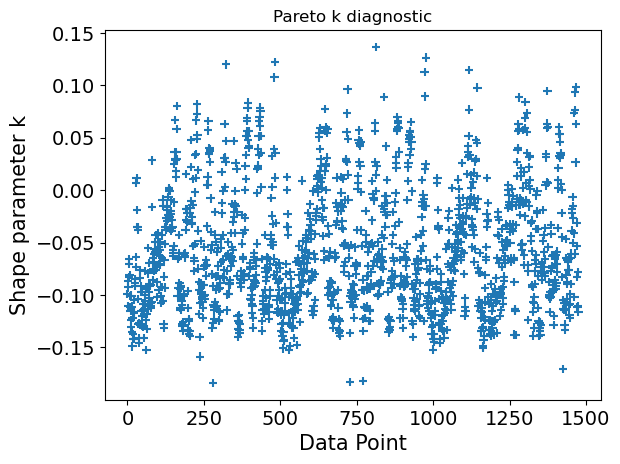

In [2]:
with pm.Model() as LH:
    '''
    1. CO + * <-> CO* (QEA)
    2. CO* + OH* -> COOH* + * (RDS)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Fast)
    4. OH- + * <-> OH* + (e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.2) # at 0V_SHE
    Gact2_0 = pm.Normal('Gact2_0', mu=0.7, sigma=0.2)

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    Gact2 = Gact2_0
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_k2 = np.log(kb_J*T/h) - Gact2/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH_Pd = log_K4 + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_CO)
    log_theta_Pd = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH_Pd]), axis=0)
    log_theta_CO = term_CO + log_theta_Pd
    log_theta_OH_Pd = term_OH_Pd + log_theta_Pd

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH_star = pm.Deterministic('theta_OH_star', pt.exp(log_theta_OH_Pd))
    theta_empty_Pd = pm.Deterministic('theta_empty_Pd', pt.exp(log_theta_Pd))

    # Rate expression
    log_rate = log_k2 + log_theta_CO + log_theta_OH_Pd + np.log(1-Ag_comp)
    rate = observables(log_rate) 

trace_LH, loo_LH = fit_and_evaluate(LH)

             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG1_0  -0.000  0.006  -0.010    0.011      0.000    0.000    1245.0    1361.0    1.0
deltaG4_0   0.036  0.004   0.029    0.042      0.000    0.000    1799.0    2338.0    1.0
Gact2_0     0.620  0.003   0.614    0.626      0.000    0.000    1305.0    1300.0    1.0
sigma_rel   1.863  0.082   1.700    2.007      0.002    0.001    1901.0    2337.0    1.0
sigma_base  0.004  0.003   0.000    0.010      0.000    0.000    2019.0    1205.0    1.0
exponent    0.562  0.015   0.535    0.589      0.000    0.000    2261.0    2145.0    1.0


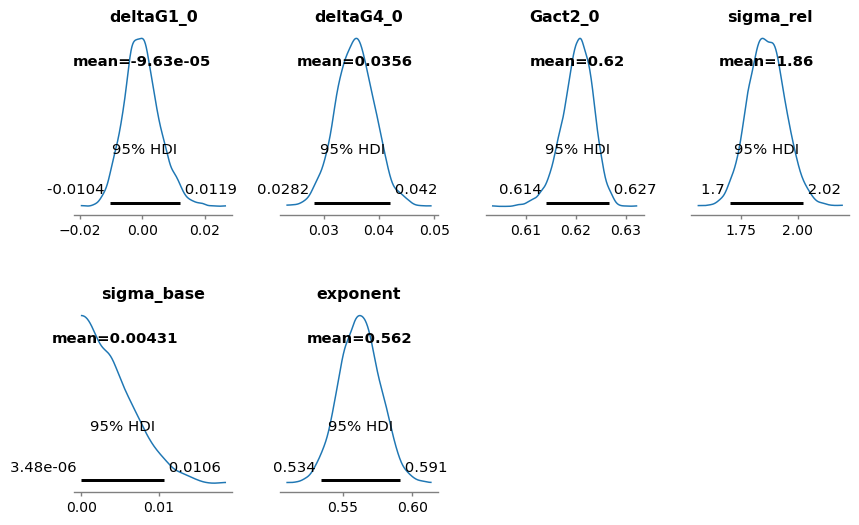

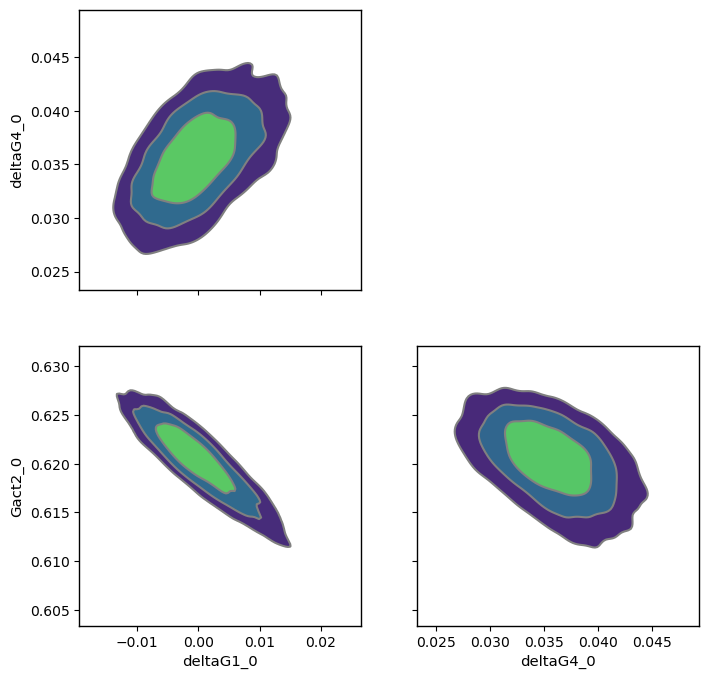

Sampling: [rate]


rate: 0.553


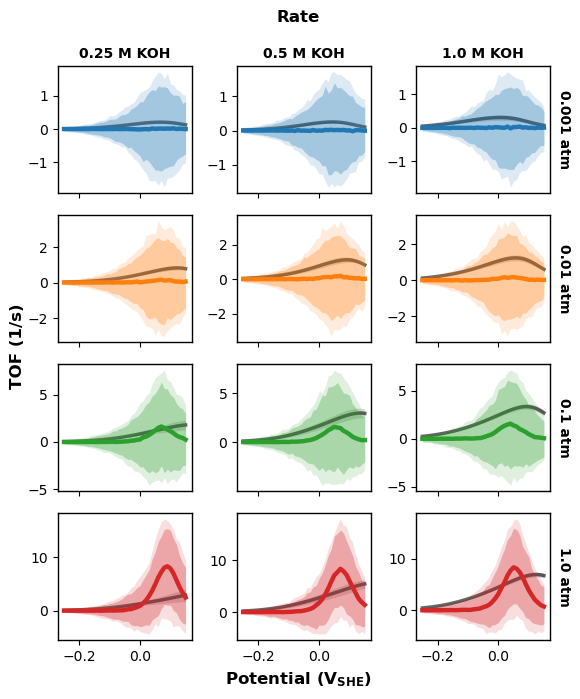

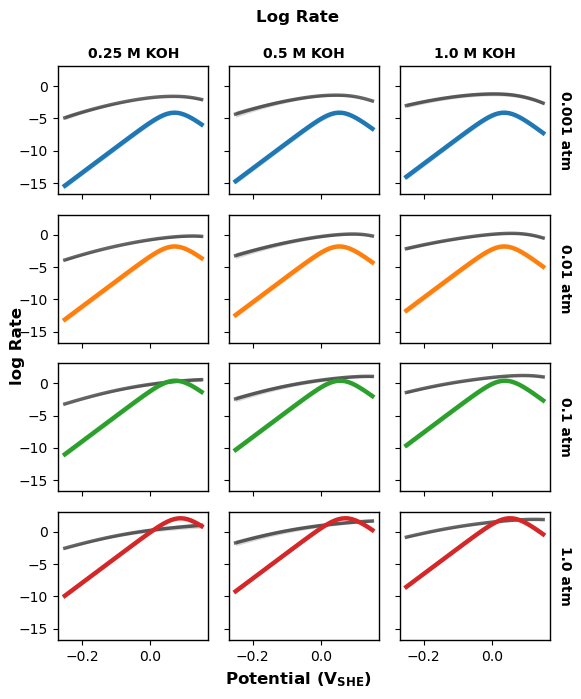

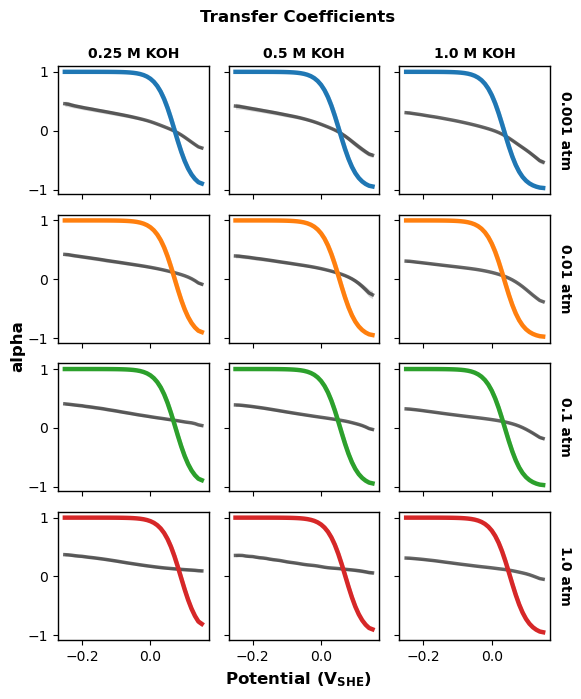

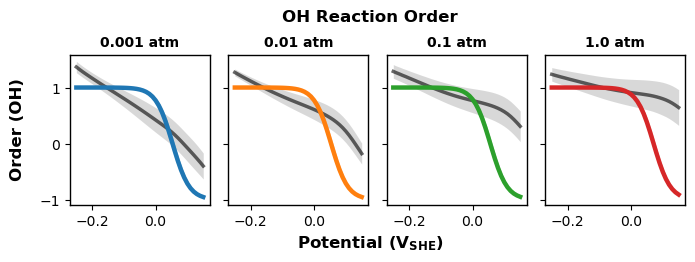

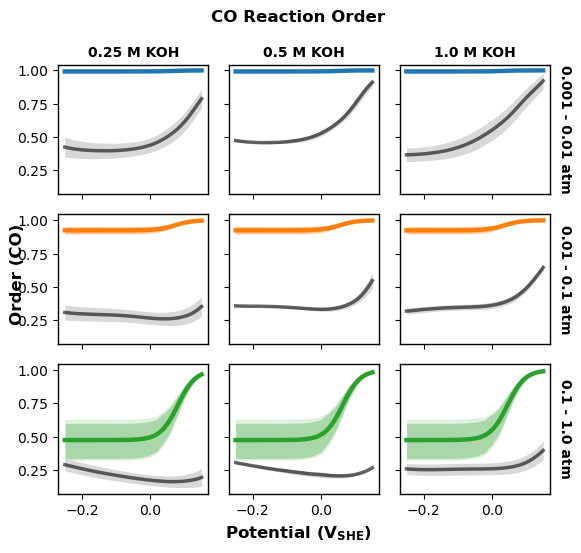

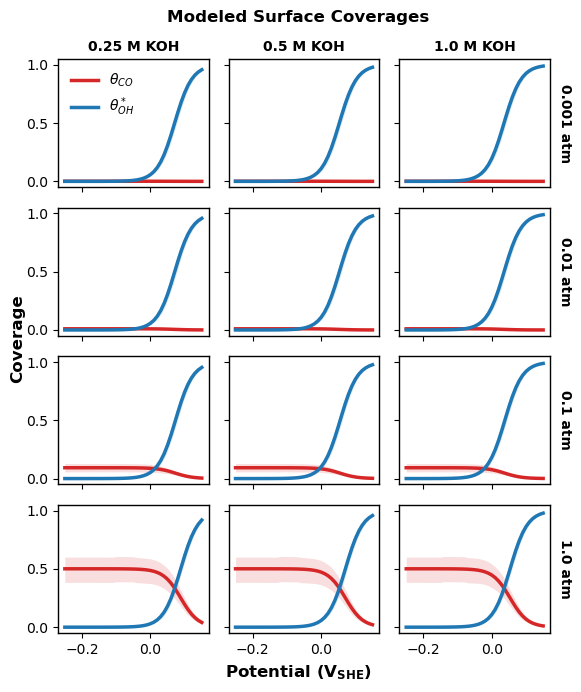

In [3]:
ppc_LH = plot_posteriors(trace_LH, LH)
plot_model_fits(trace_LH, ppc_LH); plot_coverages(trace_LH)

# BF

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.43,7
,3000,0,0.12,31
,3000,0,0.42,15
,3000,0,0.43,15


Computed from 4000 posterior samples and 1476 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  -834.57    58.19
p_loo      349.79        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     1476  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



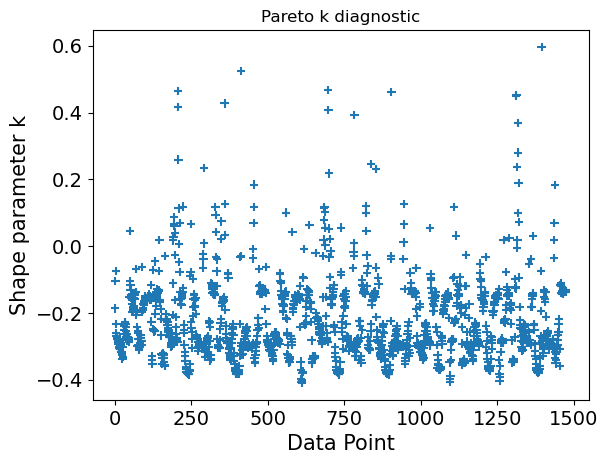

In [4]:
with pm.Model() as BF:
    '''
    1. CO + * <-> CO* (QEA)
    2. CO* + OH# -> COOH* + # (RDS)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Fast)
    4. OH- + * <-> OH* + (e-) (QEA)
    5. OH- + # <-> OH# + (e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.2) # at 0V_SHE
    deltaG5_0 = pm.Normal('deltaG5_0', mu=0.0, sigma=0.2) # at 0V_SHE
    Gact2_0 = pm.Normal('Gact2_0', mu=0.7, sigma=0.2)

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    deltaG5 = deltaG5_0 - E_in
    Gact2 = Gact2_0
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_K5 = -deltaG5/(kb_eV*T)
    log_k2 = np.log(kb_J*T/h) - Gact2/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH_Pd = log_K4 + np.log(C_KOH_in)
    term_OH_Ag = log_K5 + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_CO)
    log_theta_Pd = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH_Pd]), axis=0)
    log_theta_Ag = - pt.logsumexp(pt.stack([zeros, term_OH_Ag]), axis=0)
    log_theta_CO = term_CO + log_theta_Pd
    log_theta_OH_Pd = term_OH_Pd + log_theta_Pd
    log_theta_OH_Ag = term_OH_Ag + log_theta_Ag

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH_star = pm.Deterministic('theta_OH_star', pt.exp(log_theta_OH_Pd))
    theta_OH_pound = pm.Deterministic('theta_OH_pound', pt.exp(log_theta_OH_Ag))
    theta_empty_Pd = pm.Deterministic('theta_empty_Pd', pt.exp(log_theta_Pd))
    theta_empty_Ag = pm.Deterministic('theta_empty_Ag', pt.exp(log_theta_Ag))

    # Rate expression
    log_rate = log_k2 + log_theta_CO + log_theta_OH_Ag + np.log(Ag_comp)
    rate = observables(log_rate) 

trace_BF, loo_BF = fit_and_evaluate(BF)

             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG1_0  -0.085  0.040  -0.111   -0.010      0.020    0.012       7.0      36.0   1.53
deltaG4_0   0.094  0.104  -0.095    0.167      0.052    0.030       7.0      37.0   1.53
deltaG5_0  -0.057  0.196  -0.176    0.313      0.097    0.057       7.0      43.0   1.53
Gact2_0     0.613  0.163   0.301    0.709      0.080    0.048       7.0      40.0   1.53
sigma_rel   0.747  0.430   0.463    1.529      0.214    0.124       7.0      32.0   1.53
sigma_base  0.018  0.009   0.000    0.028      0.004    0.002       7.0      35.0   1.53
exponent    1.724  0.612   0.637    2.192      0.303    0.173       7.0      30.0   1.53


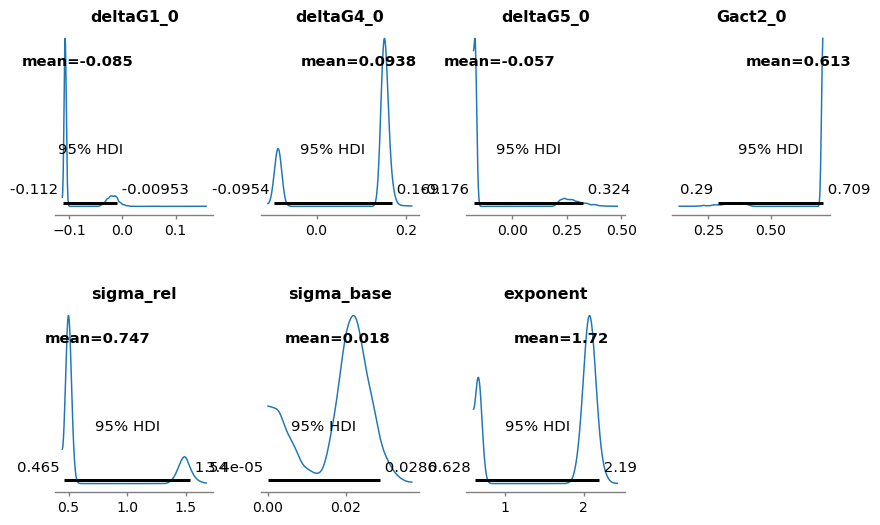

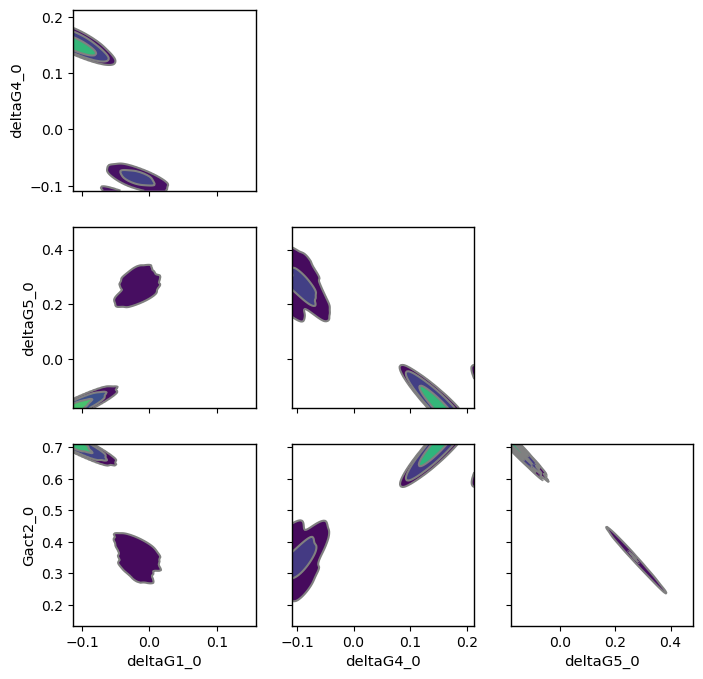

Sampling: [rate]


rate: 0.499


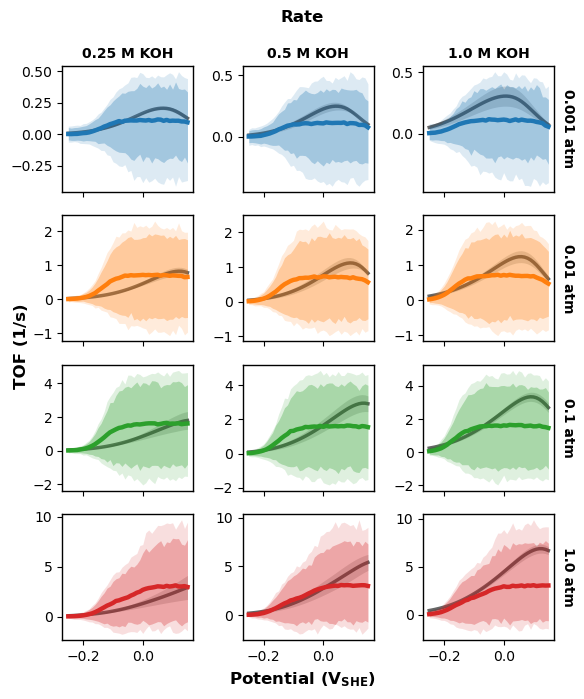

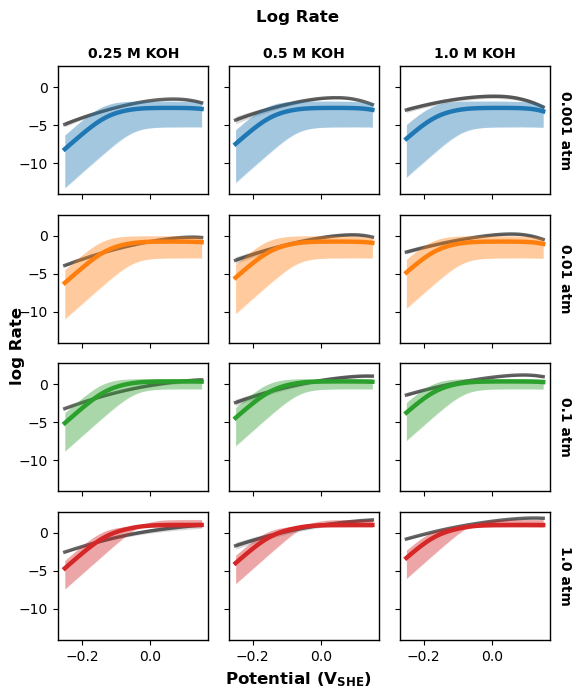

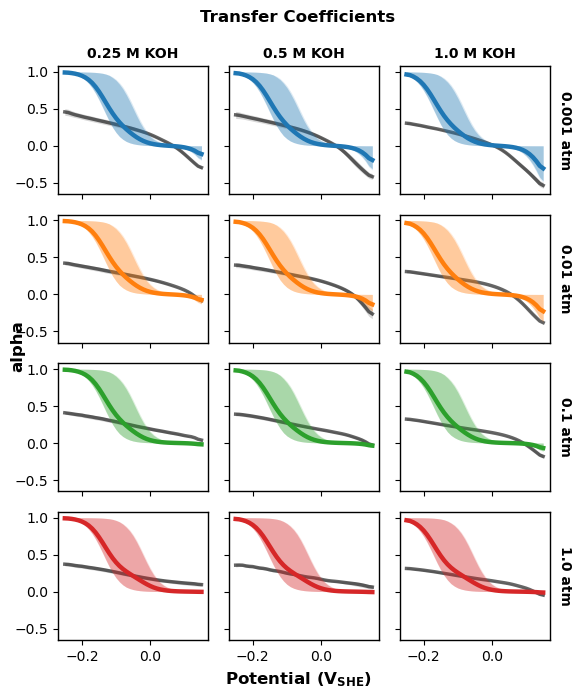

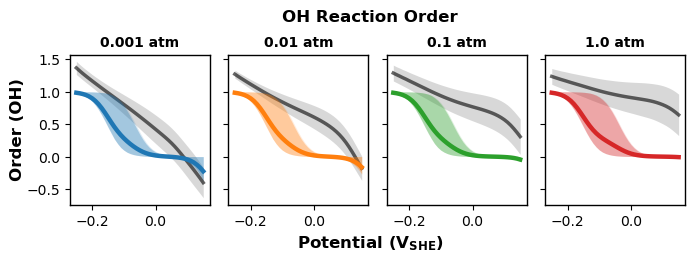

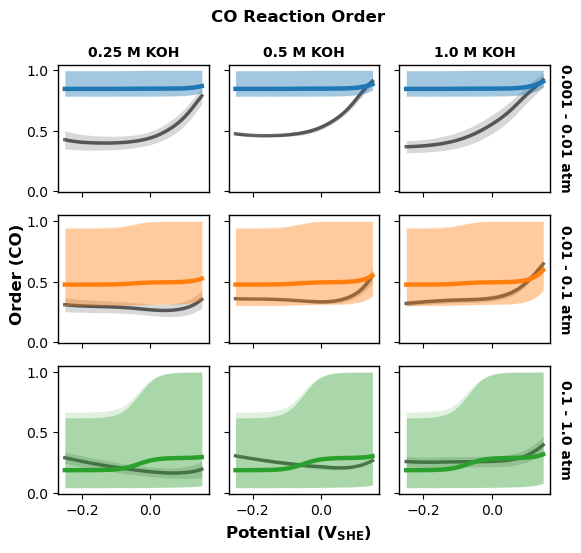

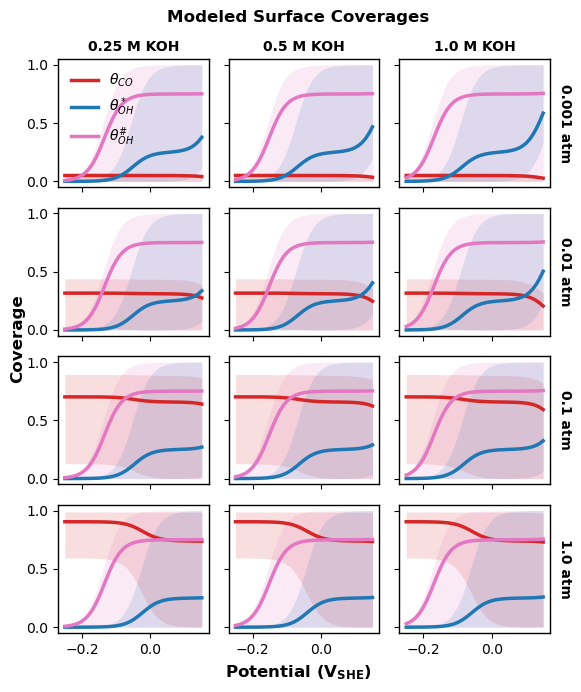

In [5]:
ppc_BF = plot_posteriors(trace_BF, BF)
plot_model_fits(trace_BF, ppc_BF); plot_coverages(trace_BF)

# ER

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.45,7
,3000,0,0.49,7
,3000,0,0.46,3
,3000,0,0.42,7


Computed from 4000 posterior samples and 1476 observations log-likelihood matrix.

         Estimate       SE
elpd_loo   334.21    57.43
p_loo        7.42        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     1476  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



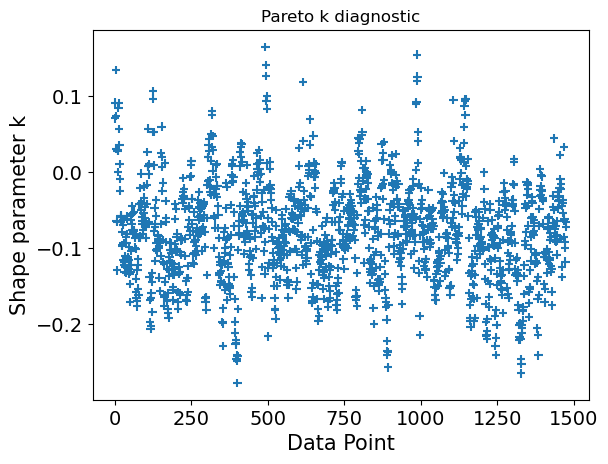

In [6]:
with pm.Model() as ER:
    '''
    1. CO + * <-> CO* (QEA)
    2. CO* + OH- -> COOH* + (e-) (RDS)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Fast)
    4. OH- + * <-> OH* + (e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.2) # at 0V_SHE
    beta_2 = pm.Beta('beta_2', alpha=5, beta=5)   
    Gact2_0 = pm.Normal('Gact2_0', mu=0.7, sigma=0.2) # at 0V_SHE

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    Gact2 = Gact2_0 - beta_2*E_in
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_k2 = np.log(kb_J*T/h) - Gact2/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH_Pd = log_K4 + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_CO)
    log_theta_Pd = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH_Pd]), axis=0)
    log_theta_CO = term_CO + log_theta_Pd
    log_theta_OH_Pd = term_OH_Pd + log_theta_Pd

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH_star = pm.Deterministic('theta_OH_star', pt.exp(log_theta_OH_Pd))
    theta_empty_Pd = pm.Deterministic('theta_empty_Pd', pt.exp(log_theta_Pd))

    # Rate expression
    log_rate = log_k2 + log_theta_CO + np.log(C_KOH_in)
    rate = observables(log_rate) 

trace_ER, loo_ER = fit_and_evaluate(ER)

             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG1_0  -0.122  0.001  -0.124   -0.120      0.000    0.000    2076.0    2433.0    1.0
deltaG4_0   0.066  0.002   0.062    0.069      0.000    0.000    2278.0    2487.0    1.0
Gact2_0     0.712  0.000   0.712    0.713      0.000    0.000    2767.0    2842.0    1.0
beta_2      0.226  0.003   0.220    0.232      0.000    0.000    2581.0    2762.0    1.0
sigma_rel   0.315  0.008   0.299    0.330      0.000    0.000    3684.0    2987.0    1.0
sigma_base  0.001  0.001   0.000    0.004      0.000    0.000    2429.0    1390.0    1.0
exponent    1.813  0.040   1.736    1.885      0.001    0.001    2891.0    2937.0    1.0


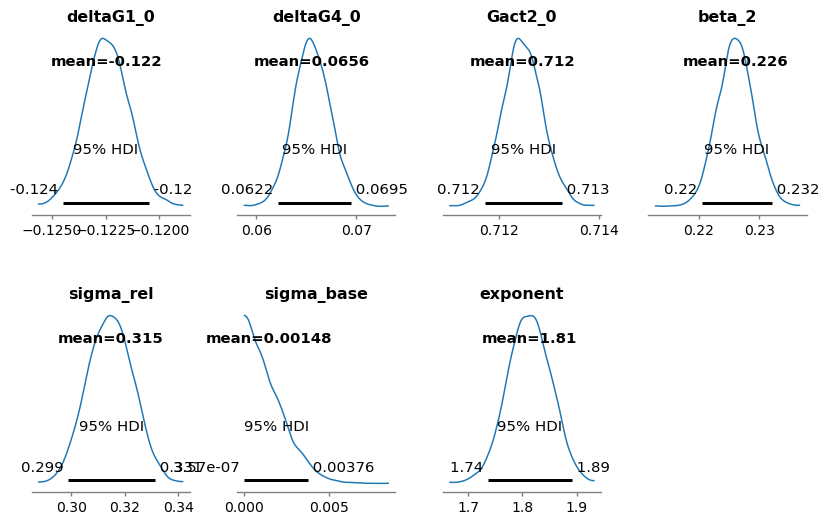

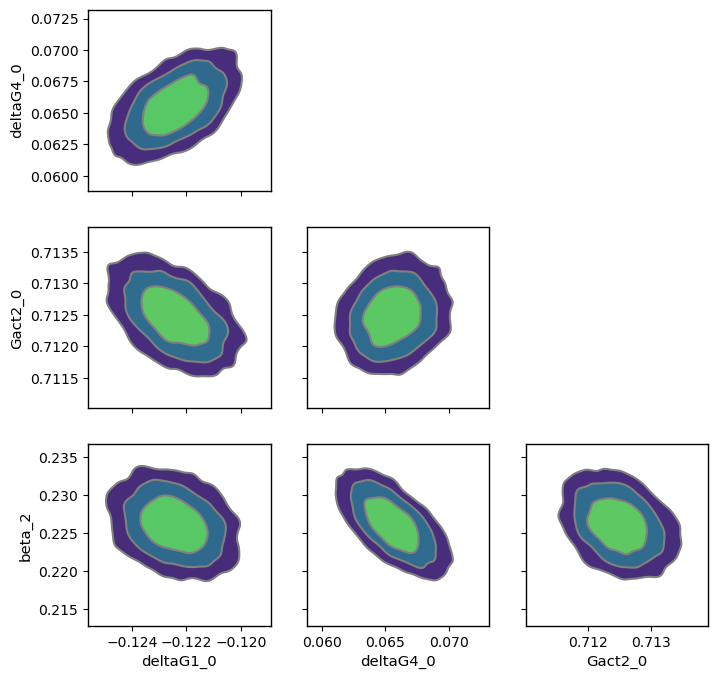

Sampling: [rate]


rate: 0.770


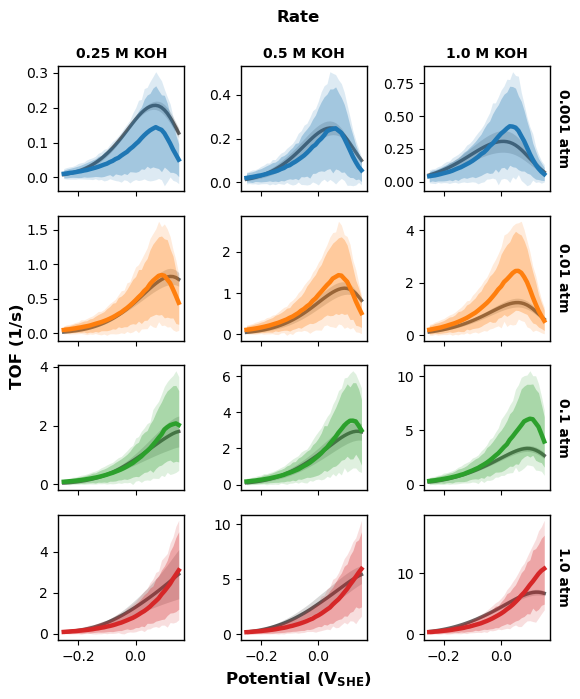

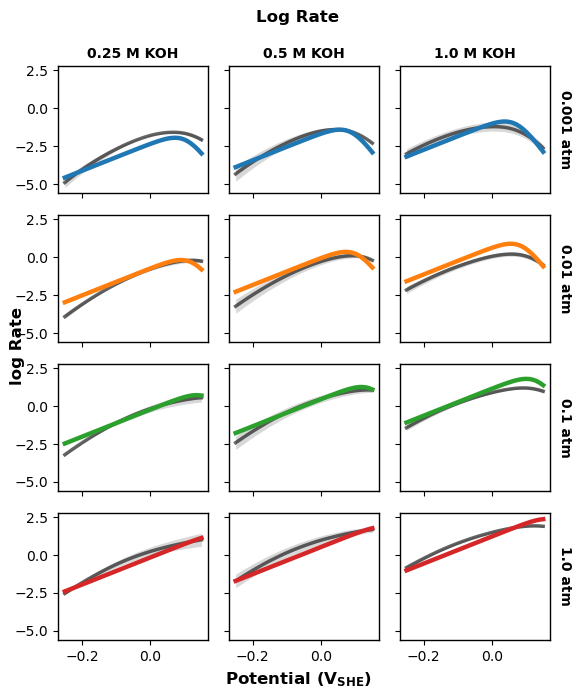

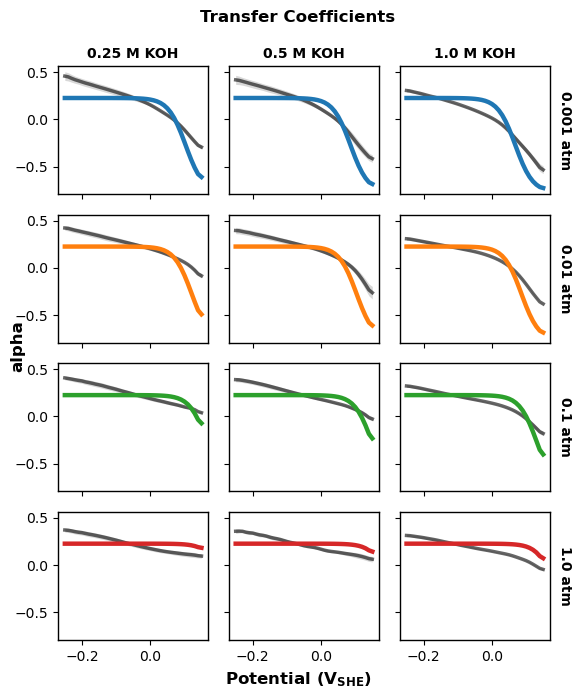

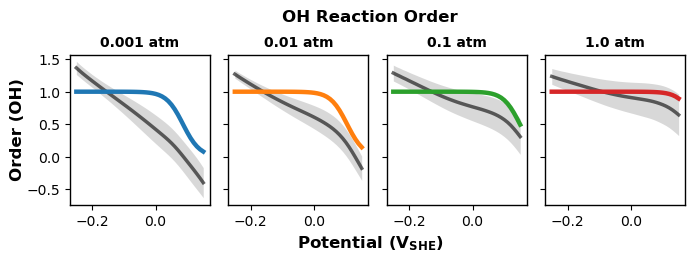

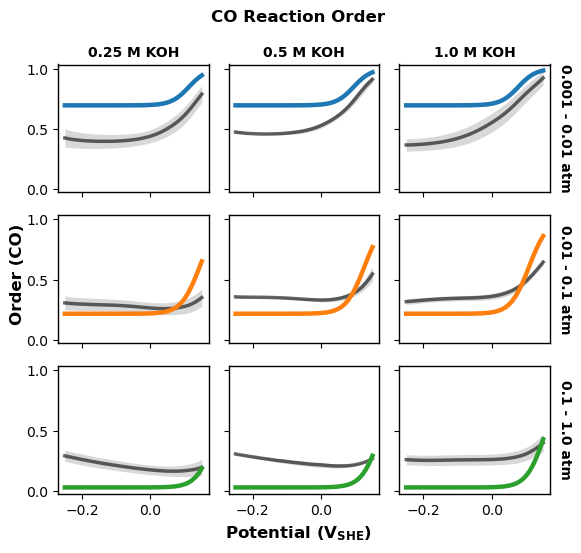

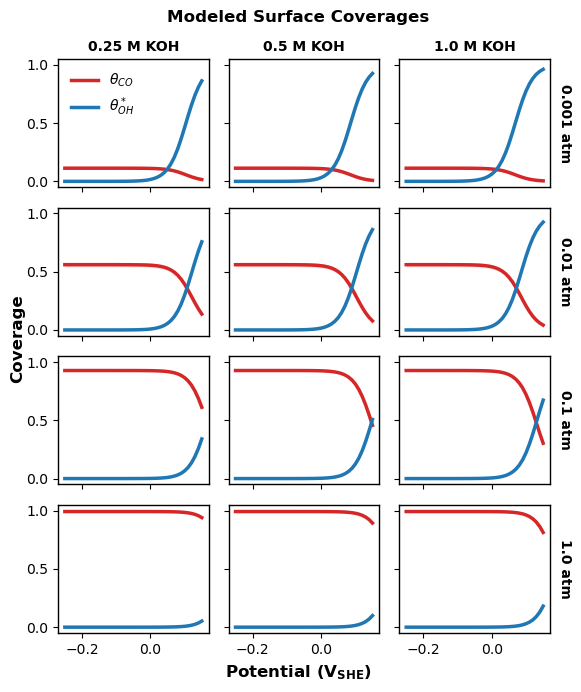

In [7]:
ppc_ER = plot_posteriors(trace_ER, ER)
plot_model_fits(trace_ER, ppc_ER); plot_coverages(trace_ER)

# BF ER

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.38,15
,3000,0,0.38,15
,3000,0,0.38,7
,3000,0,0.34,7


Computed from 4000 posterior samples and 1476 observations log-likelihood matrix.

         Estimate       SE
elpd_loo   467.59    56.70
p_loo       11.36        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     1476  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



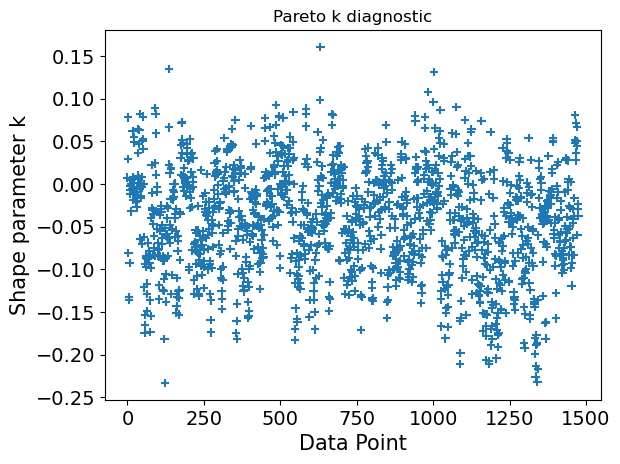

In [8]:
with pm.Model() as BF_ER:
    '''
    1. CO + * <-> CO* (QEA)
    2a. CO* + OH# -> COOH* + # (RDS) (BF)
    2b. CO* + OH- -> COOH* + (e-) (RDS) (ER)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Fast)
    4. OH- + * <-> OH* + (e-) (QEA)
    5. OH- + # <-> OH# + (e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.2) # at 0V_SHE
    deltaG5_0 = pm.Normal('deltaG5_0', mu=0.0, sigma=0.2) # at 0V_SHE
    beta_2 = pm.Beta('beta_2', alpha=5, beta=5)
    Gact2_BF_0 = pm.Normal('Gact2_BF_0', mu=0.7, sigma=0.2)
    Gact2_ER_0 = pm.Normal('Gact2_ER_0', mu=0.7, sigma=0.2) # at 0V_SHE

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    deltaG5 = deltaG5_0 - E_in
    Gact2_BF = Gact2_BF_0
    Gact2_ER = Gact2_ER_0 - beta_2*E_in
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_K5 = -deltaG5/(kb_eV*T)
    log_k2_BF = np.log(kb_J*T/h) - Gact2_BF/(kb_eV*T)
    log_k2_ER = np.log(kb_J*T/h) - Gact2_ER/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH_Pd = log_K4 + np.log(C_KOH_in)
    term_OH_Ag = log_K5 + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_CO)
    log_theta_Pd = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH_Pd]), axis=0)
    log_theta_Ag = - pt.logsumexp(pt.stack([zeros, term_OH_Ag]), axis=0)
    log_theta_CO = term_CO + log_theta_Pd
    log_theta_OH_Pd = term_OH_Pd + log_theta_Pd
    log_theta_OH_Ag = term_OH_Ag + log_theta_Ag

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH_star = pm.Deterministic('theta_OH_star', pt.exp(log_theta_OH_Pd))
    theta_OH_pound = pm.Deterministic('theta_OH_pound', pt.exp(log_theta_OH_Ag))
    theta_empty_Pd = pm.Deterministic('theta_empty_Pd', pt.exp(log_theta_Pd))
    theta_empty_Ag = pm.Deterministic('theta_empty_Ag', pt.exp(log_theta_Ag))

    # Rate expression
    log_rate_BF = log_k2_BF + log_theta_CO + log_theta_OH_Ag + np.log(Ag_comp)
    log_rate_ER = log_k2_ER + log_theta_CO + np.log(C_KOH_in)
    log_rate = pt.logaddexp(log_rate_BF, log_rate_ER)
    rate = observables(log_rate) 

trace_BF_ER, loo_BF_ER = fit_and_evaluate(BF_ER)

             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG1_0  -0.120  0.001  -0.122   -0.118      0.000    0.000    2497.0    2597.0    1.0
deltaG4_0   0.081  0.002   0.077    0.085      0.000    0.000    2280.0    2565.0    1.0
deltaG5_0  -0.122  0.006  -0.133   -0.112      0.000    0.000    2311.0    2490.0    1.0
Gact2_BF_0  0.741  0.002   0.737    0.745      0.000    0.000    1855.0    2551.0    1.0
Gact2_ER_0  0.720  0.001   0.719    0.722      0.000    0.000    2194.0    2422.0    1.0
beta_2      0.206  0.004   0.198    0.214      0.000    0.000    1921.0    2275.0    1.0
sigma_rel   0.293  0.008   0.277    0.308      0.000    0.000    3832.0    3272.0    1.0
sigma_base  0.001  0.001   0.000    0.004      0.000    0.000    2072.0    1271.0    1.0
exponent    1.838  0.047   1.748    1.924      0.001    0.001    2795.0    3015.0    1.0


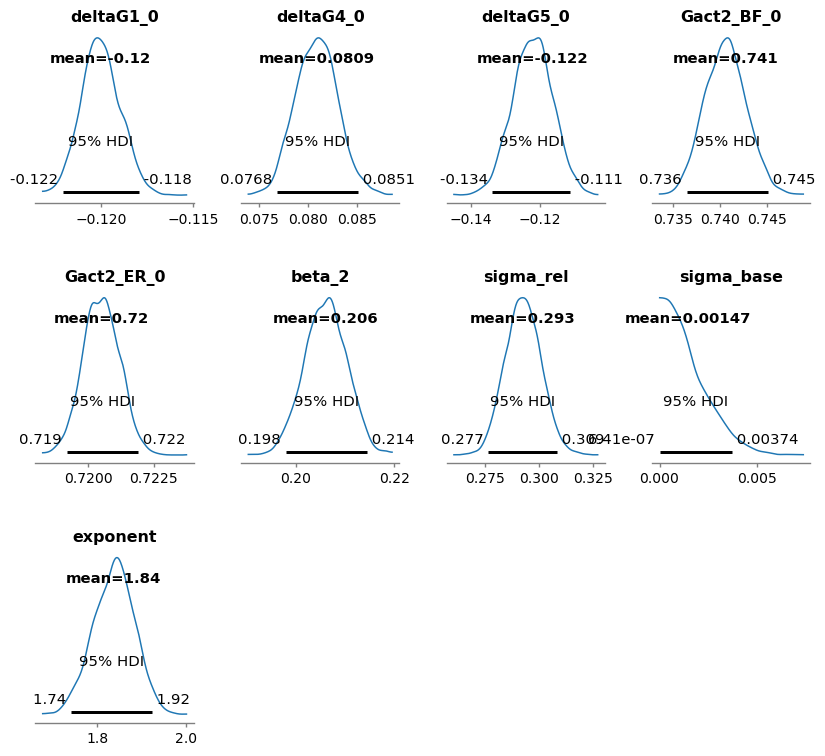

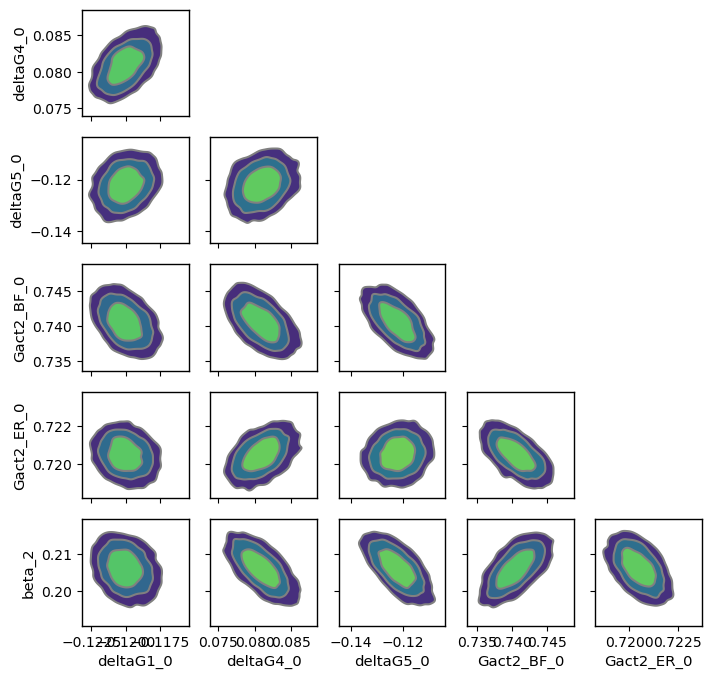

Sampling: [rate]


rate: 0.766


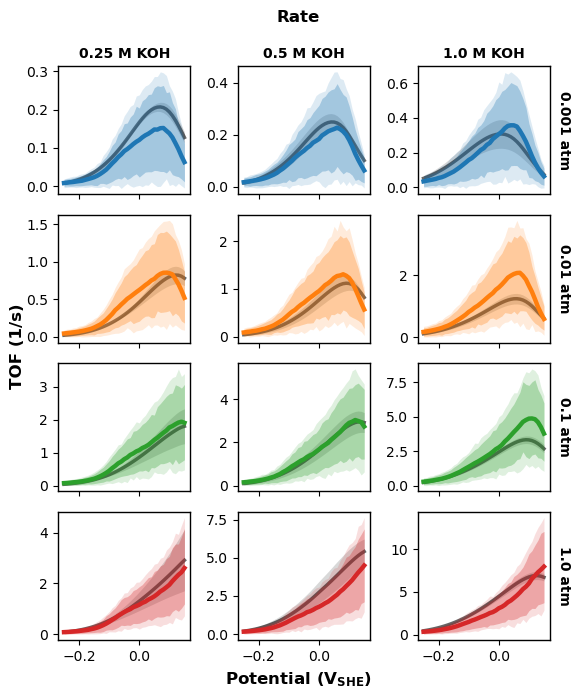

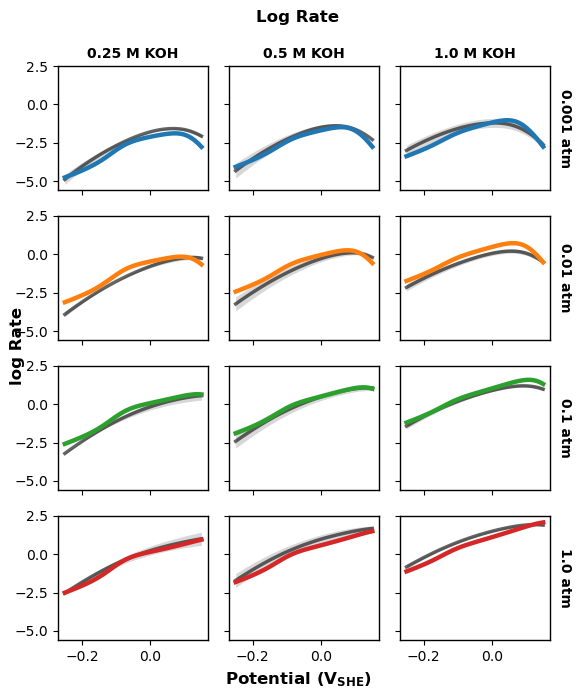

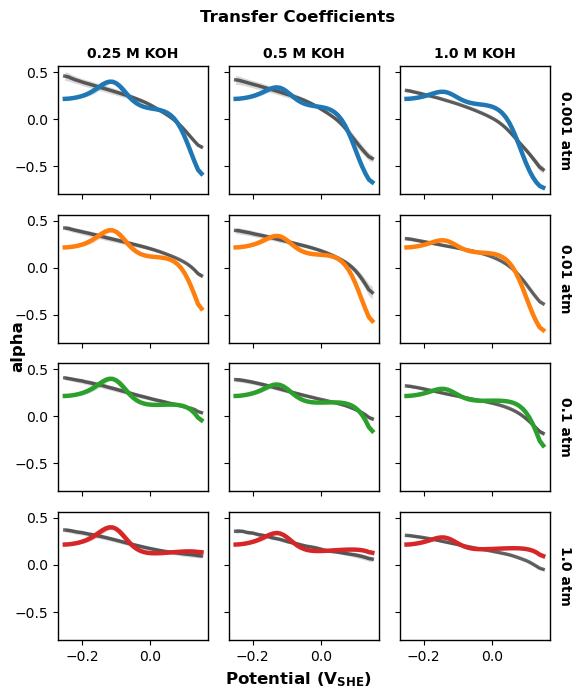

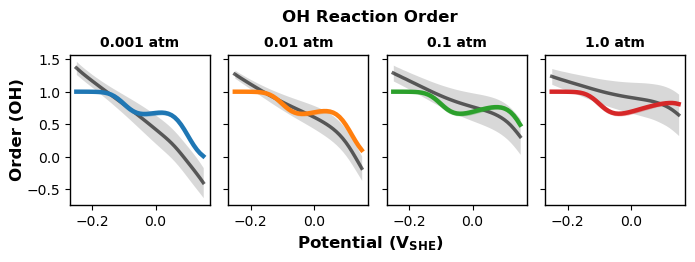

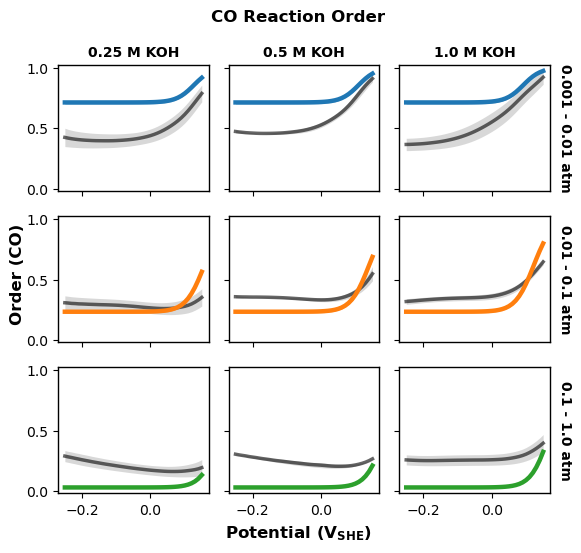

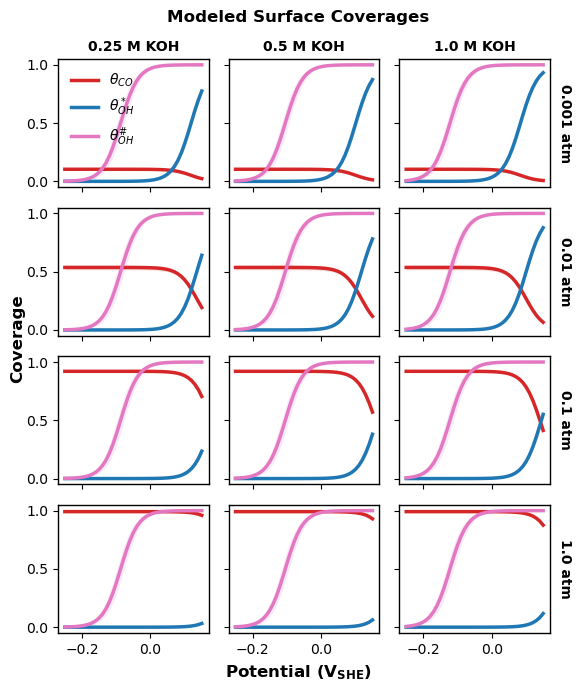

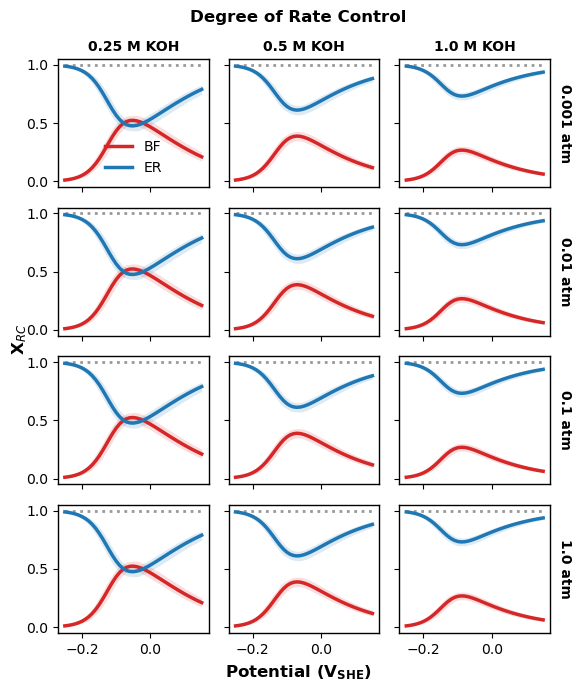

In [9]:
ppc_BF_ER = plot_posteriors(trace_BF_ER, BF_ER)
plot_model_fits(trace_BF_ER, ppc_BF_ER); plot_coverages(trace_BF_ER)
plot_drc(BF_ER, trace_BF_ER, perturb_vars=['Gact2_BF_0', 'Gact2_ER_0'], perturb_labels=['BF', 'ER'])

# BF ER LH

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.34,15
,3000,0,0.39,15
,3000,0,0.37,15
,3000,0,0.42,15


Computed from 4000 posterior samples and 1476 observations log-likelihood matrix.

         Estimate       SE
elpd_loo   481.72    56.67
p_loo       11.66        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     1476  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



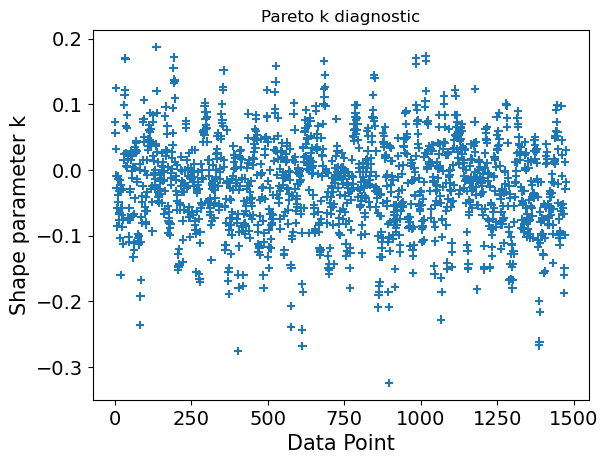

In [10]:
with pm.Model() as BF_ER_LH:
    '''
    1. CO + * <-> CO* (QEA)
    2a. CO* + OH# -> COOH* + # (RDS) (BF)
    2b. CO* + OH- -> COOH* + (e-) (RDS) (ER)
    2c. CO* + OH* -> COOH* + * (RDS) (LH)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Fast)
    4. OH- + * <-> OH* + (e-) (QEA)
    5. OH- + # <-> OH# + (e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.2) # at 0V_SHE
    deltaG5_0 = pm.Normal('deltaG5_0', mu=0.0, sigma=0.2) # at 0V_SHE
    beta_2 = pm.Beta('beta_2', alpha=5, beta=5)
    Gact2_BF_0 = pm.Normal('Gact2_BF_0', mu=0.7, sigma=0.2)
    Gact2_ER_0 = pm.Normal('Gact2_ER_0', mu=0.7, sigma=0.2) # at 0V_SHE
    Gact2_LH_0 = pm.Normal('Gact2_LH_0', mu=0.7, sigma=0.2)

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    deltaG5 = deltaG5_0 - E_in
    Gact2_BF = Gact2_BF_0
    Gact2_ER = Gact2_ER_0 - beta_2*E_in
    Gact2_LH = Gact2_LH_0
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_K5 = -deltaG5/(kb_eV*T)
    log_k2_BF = np.log(kb_J*T/h) - Gact2_BF/(kb_eV*T)
    log_k2_ER = np.log(kb_J*T/h) - Gact2_ER/(kb_eV*T)
    log_k2_LH = np.log(kb_J*T/h) - Gact2_LH/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH_Pd = log_K4 + np.log(C_KOH_in)
    term_OH_Ag = log_K5 + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_CO)
    log_theta_Pd = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH_Pd]), axis=0)
    log_theta_Ag = - pt.logsumexp(pt.stack([zeros, term_OH_Ag]), axis=0)
    log_theta_CO = term_CO + log_theta_Pd
    log_theta_OH_Pd = term_OH_Pd + log_theta_Pd
    log_theta_OH_Ag = term_OH_Ag + log_theta_Ag

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH_star = pm.Deterministic('theta_OH_star', pt.exp(log_theta_OH_Pd))
    theta_OH_pound = pm.Deterministic('theta_OH_pound', pt.exp(log_theta_OH_Ag))
    theta_empty_Pd = pm.Deterministic('theta_empty_Pd', pt.exp(log_theta_Pd))
    theta_empty_Ag = pm.Deterministic('theta_empty_Ag', pt.exp(log_theta_Ag))

    # Rate expression
    log_rate_BF = log_k2_BF + log_theta_CO + log_theta_OH_Ag + np.log(Ag_comp)
    log_rate_ER = log_k2_ER + log_theta_CO + np.log(C_KOH_in)
    log_rate_LH = log_k2_LH + log_theta_CO + log_theta_OH_Pd + np.log(1.0 - Ag_comp)
    log_rate = pt.logsumexp(pt.stack([log_rate_BF, log_rate_ER, log_rate_LH]), axis=0)
    rate = observables(log_rate) 

trace_BF_ER_LH, loo_BF_ER_LH = fit_and_evaluate(BF_ER_LH)

             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG1_0  -0.119  0.001  -0.121   -0.117      0.000    0.000    2381.0    2080.0    1.0
deltaG4_0   0.073  0.002   0.069    0.078      0.000    0.000    2894.0    2549.0    1.0
deltaG5_0  -0.126  0.006  -0.136   -0.116      0.000    0.000    2738.0    3086.0    1.0
Gact2_BF_0  0.742  0.002   0.738    0.746      0.000    0.000    2021.0    2606.0    1.0
Gact2_ER_0  0.720  0.001   0.719    0.722      0.000    0.000    2616.0    2996.0    1.0
Gact2_LH_0  0.714  0.005   0.705    0.724      0.000    0.000    3585.0    2342.0    1.0
beta_2      0.205  0.004   0.197    0.212      0.000    0.000    2343.0    2780.0    1.0
sigma_rel   0.289  0.008   0.275    0.304      0.000    0.000    4236.0    3170.0    1.0
sigma_base  0.002  0.001   0.000    0.004      0.000    0.000    2946.0    1876.0    1.0
exponent    1.831  0.046   1.745    1.919      0.001    0.001    2643.0    2713.0    1.0


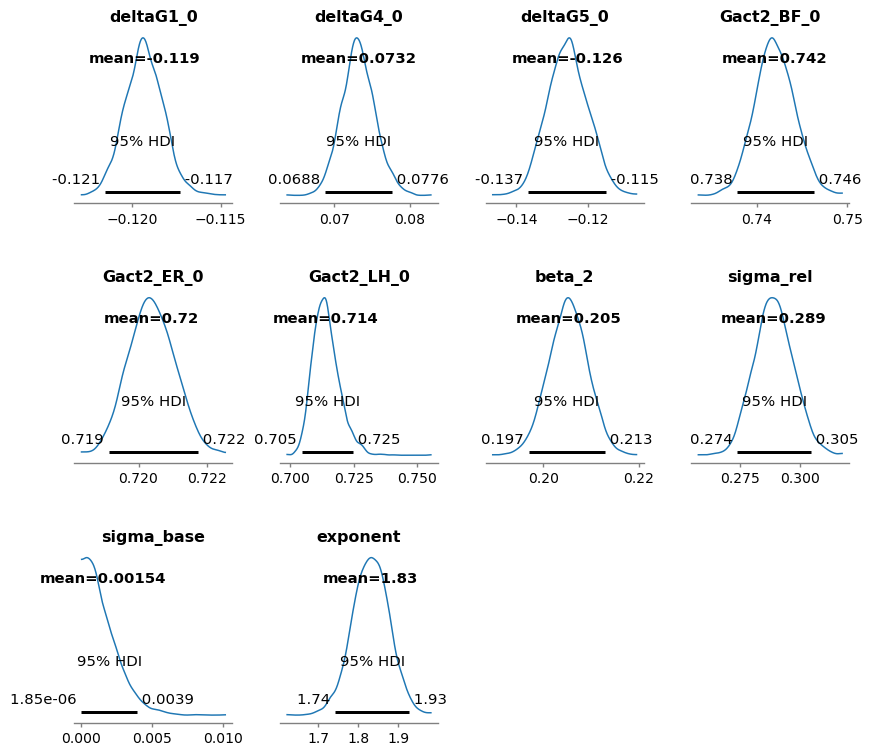

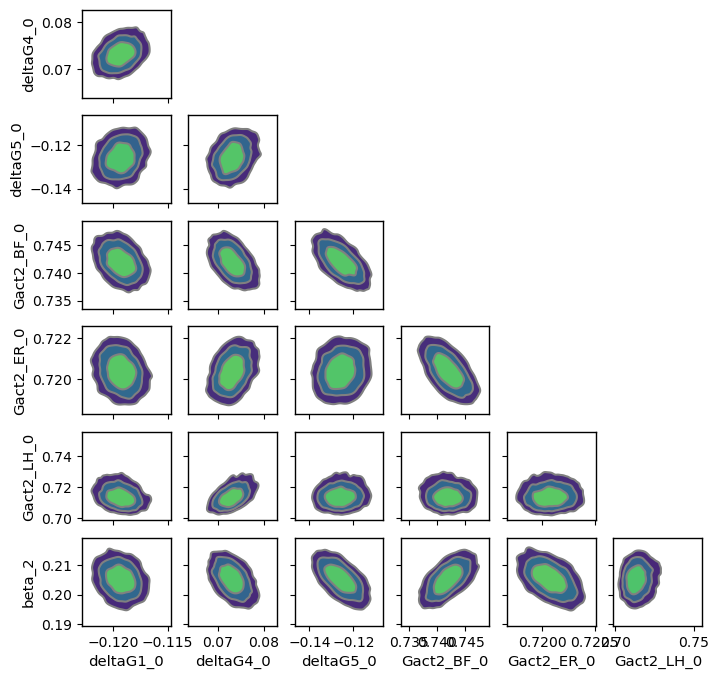

Sampling: [rate]


rate: 0.768


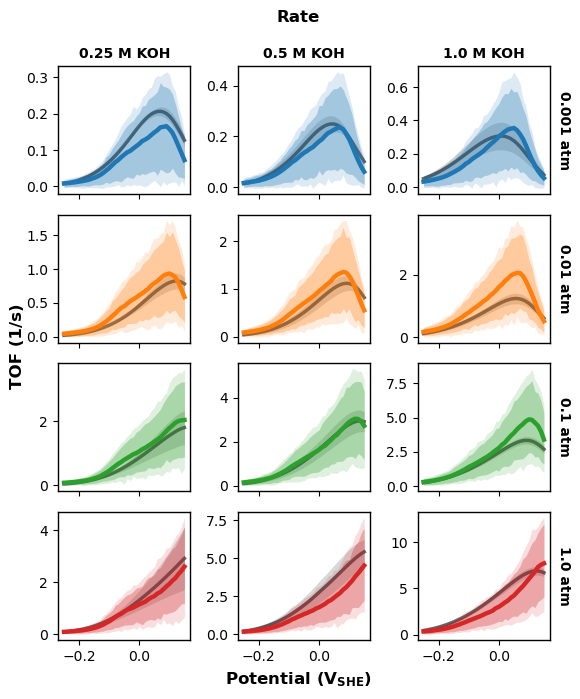

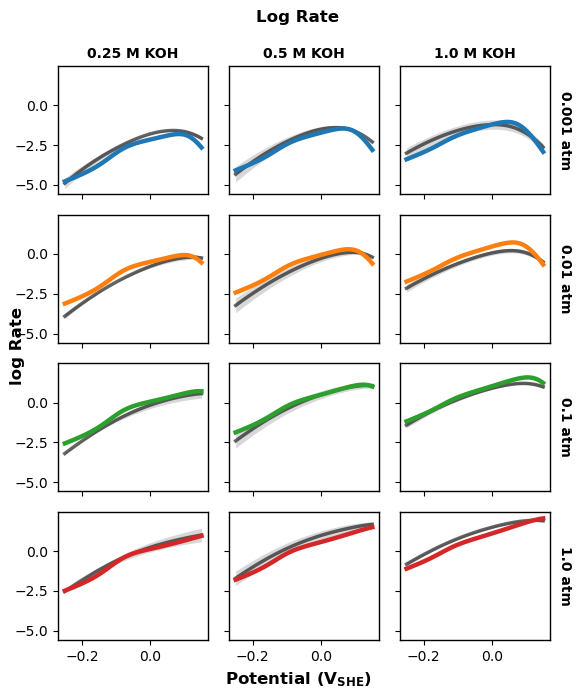

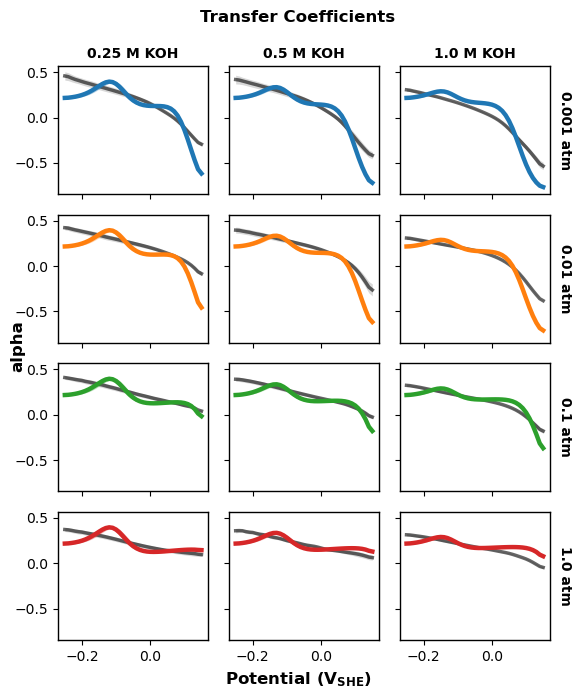

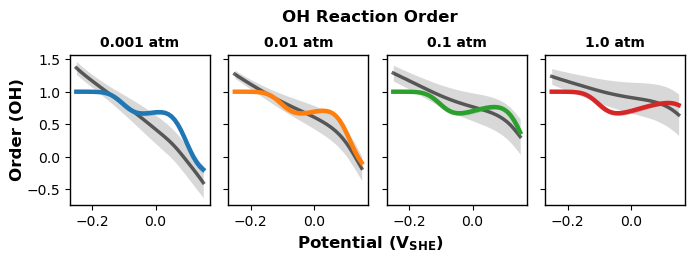

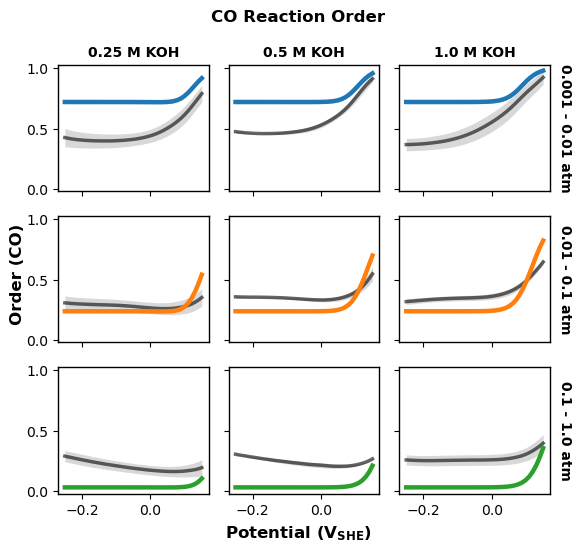

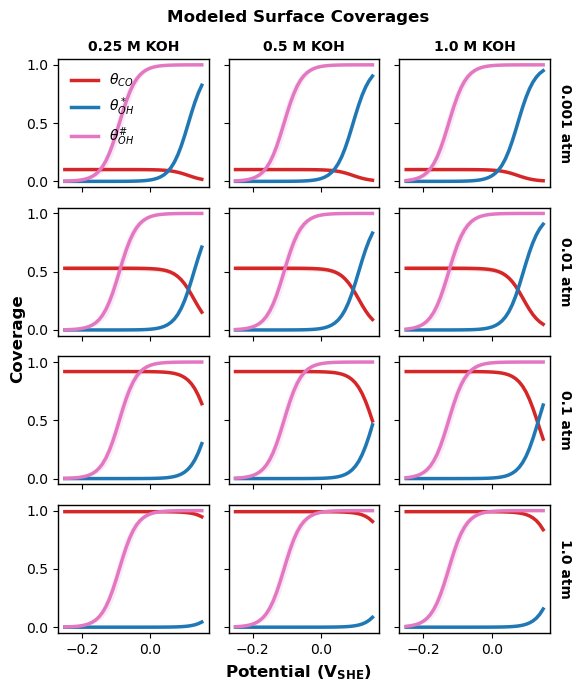

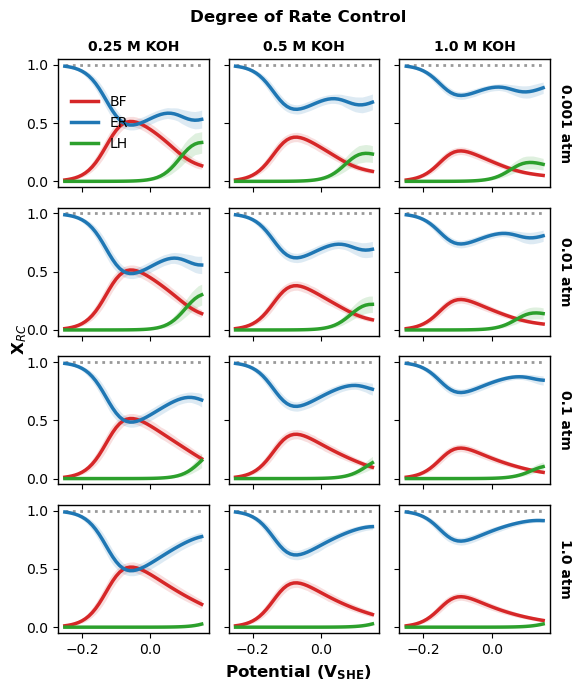

In [11]:
ppc_BF_ER_LH = plot_posteriors(trace_BF_ER_LH, BF_ER_LH)
plot_model_fits(trace_BF_ER_LH, ppc_BF_ER_LH); plot_coverages(trace_BF_ER_LH)
plot_drc(BF_ER_LH, trace_BF_ER_LH, perturb_vars=['Gact2_BF_0', 'Gact2_ER_0', 'Gact2_LH_0'], perturb_labels=['BF', 'ER', 'LH'])

# BF PCT Ag

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.25,47
,3000,0,0.26,47
,3000,0,0.26,15
,3000,0,0.24,31


Computed from 4000 posterior samples and 1476 observations log-likelihood matrix.

         Estimate       SE
elpd_loo   476.78    55.25
p_loo        9.46        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     1476  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



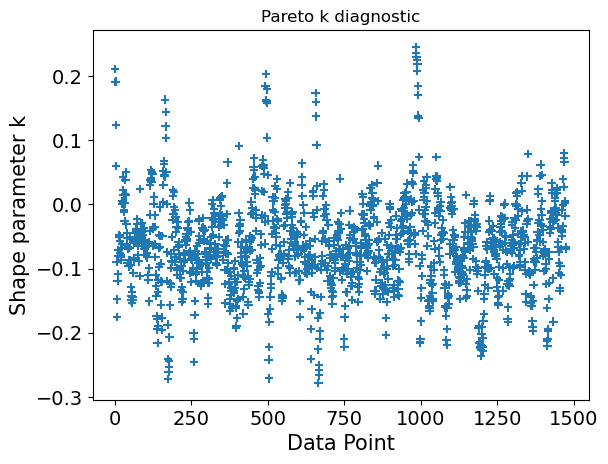

In [12]:
with pm.Model() as BF_PCT_Ag:
    '''
    1. CO + * <-> CO* (QEA)
    2. CO* + OH(q-1)# -> COOH* + # + (1-q)(e-) (RDS) (BF)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Fast)
    4. OH- + * <-> OH* + (e-) (QEA)
    5. OH- + # <-> OH(q-1)# + (q)(e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.2) # at 0V_SHE
    deltaG5_0 = pm.Normal('deltaG5_0', mu=0.0, sigma=0.2) # at 0V_SHE
    beta_2 = pm.Beta('beta_2', alpha=5, beta=5)
    q = pm.Beta('q', alpha=1, beta=1)
    Gact2_0 = pm.Normal('Gact2_0', mu=0.7, sigma=0.2)

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    deltaG5 = deltaG5_0 - q * E_in
    Gact2 = Gact2_0 - beta_2 * (1.0 - q) * E_in
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_K5 = -deltaG5/(kb_eV*T)
    log_k2 = np.log(kb_J*T/h) - Gact2/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH_Pd = log_K4 + np.log(C_KOH_in)
    term_OH_Ag = log_K5 + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_CO)
    log_theta_Pd = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH_Pd]), axis=0)
    log_theta_Ag = - pt.logsumexp(pt.stack([zeros, term_OH_Ag]), axis=0)
    log_theta_CO = term_CO + log_theta_Pd
    log_theta_OH_Pd = term_OH_Pd + log_theta_Pd
    log_theta_OH_Ag = term_OH_Ag + log_theta_Ag

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH_star = pm.Deterministic('theta_OH_star', pt.exp(log_theta_OH_Pd))
    theta_OH_pound = pm.Deterministic('theta_OH_pound', pt.exp(log_theta_OH_Ag))
    theta_empty_Pd = pm.Deterministic('theta_empty_Pd', pt.exp(log_theta_Pd))
    theta_empty_Ag = pm.Deterministic('theta_empty_Ag', pt.exp(log_theta_Ag))

    # Rate expression
    log_rate_BF = log_k2 + log_theta_CO + log_theta_OH_Ag + np.log(Ag_comp)
    log_rate = log_rate_BF
    rate = observables(log_rate) 

trace_BF_PCT_Ag, loo_BF_PCT_Ag = fit_and_evaluate(BF_PCT_Ag)

             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG1_0  -0.119  0.001  -0.121   -0.116      0.000    0.000    2600.0    2919.0   1.00
deltaG4_0   0.081  0.002   0.077    0.085      0.000    0.000    2042.0    2771.0   1.00
deltaG5_0   0.012  0.002   0.007    0.016      0.000    0.000    1012.0    1554.0   1.01
Gact2_0     0.674  0.002   0.670    0.677      0.000    0.000    1020.0    1483.0   1.01
beta_2      0.030  0.010   0.011    0.050      0.000    0.000    1646.0    1610.0   1.00
q           0.243  0.010   0.224    0.260      0.000    0.000    1751.0    2100.0   1.00
sigma_rel   0.284  0.008   0.269    0.299      0.000    0.000    3966.0    3161.0   1.00
sigma_base  0.001  0.001   0.000    0.003      0.000    0.000    2670.0    1441.0   1.00
exponent    1.769  0.048   1.677    1.857      0.001    0.001    2675.0    2756.0   1.00


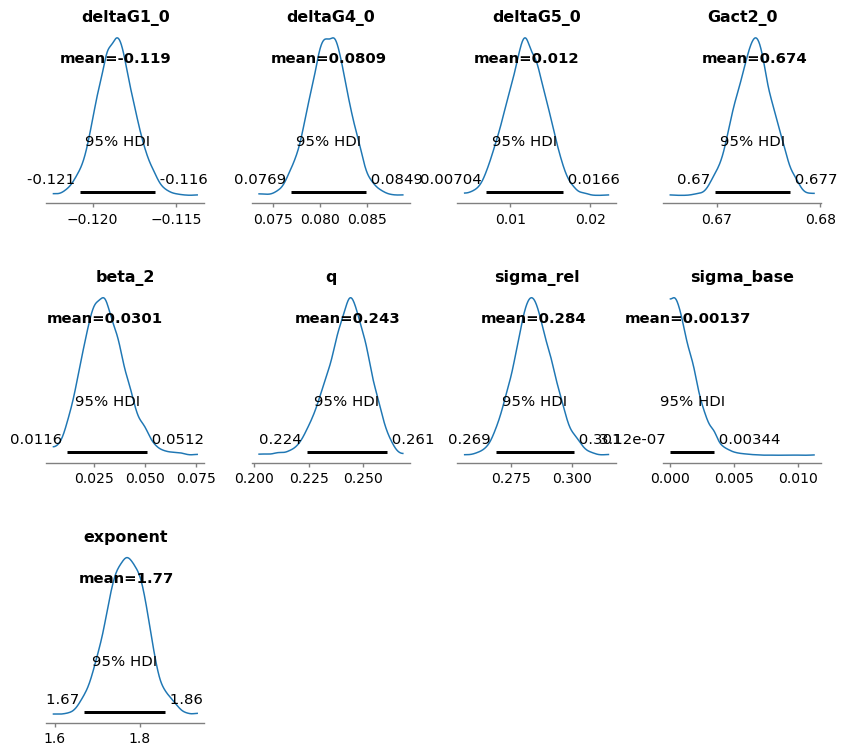

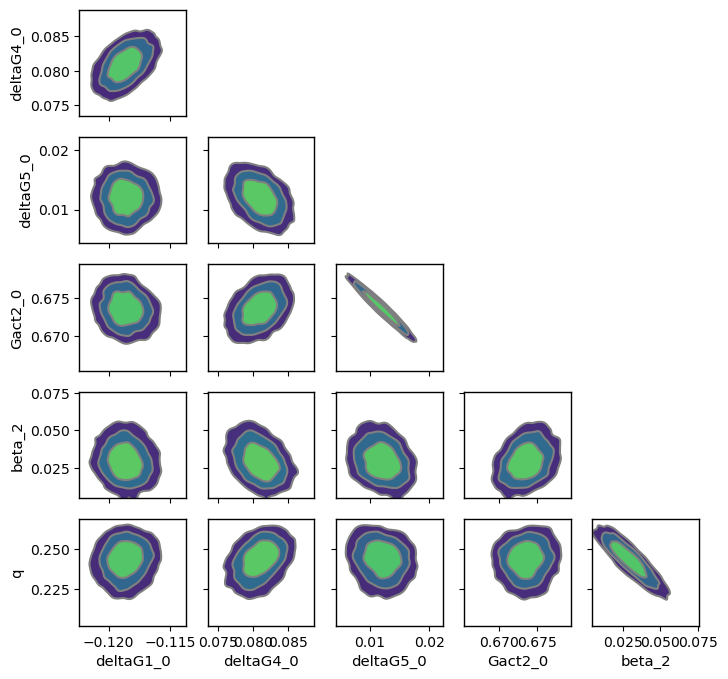

Sampling: [rate]


rate: 0.770


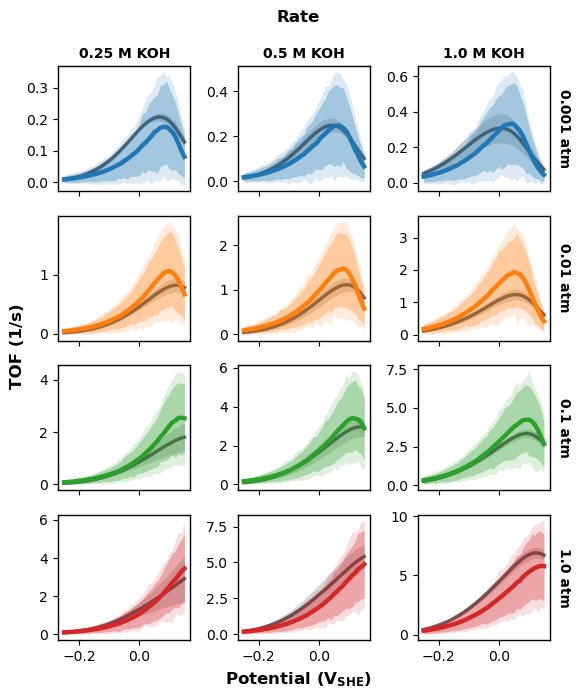

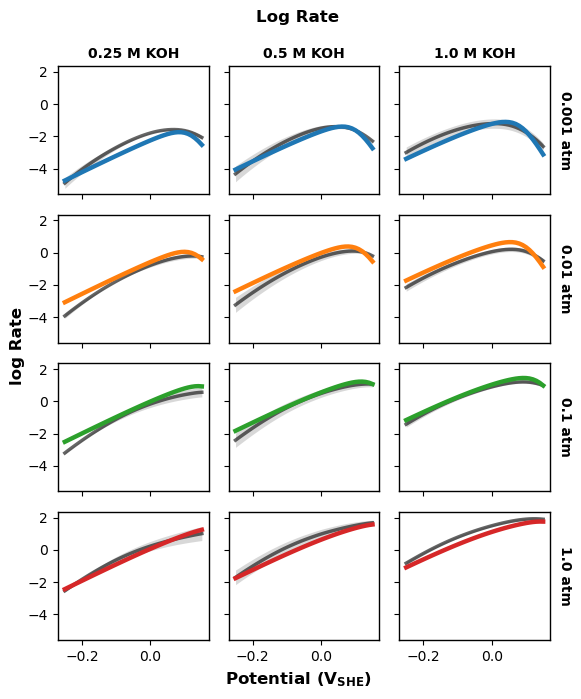

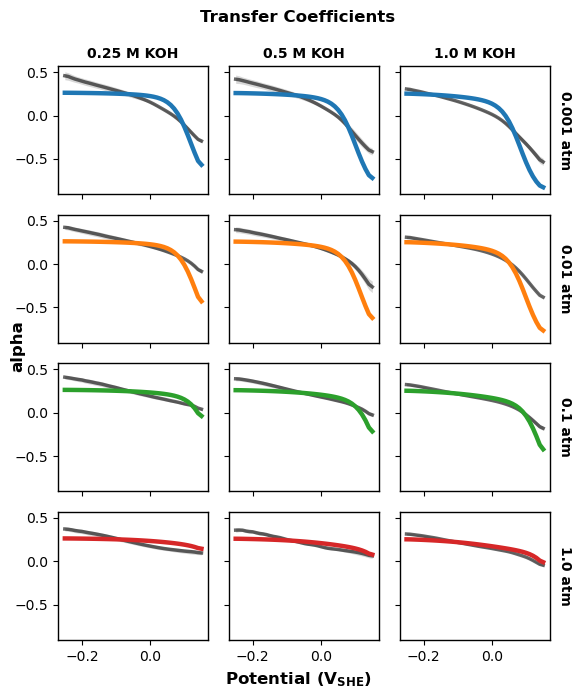

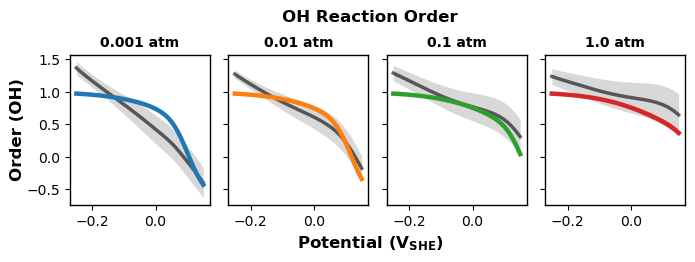

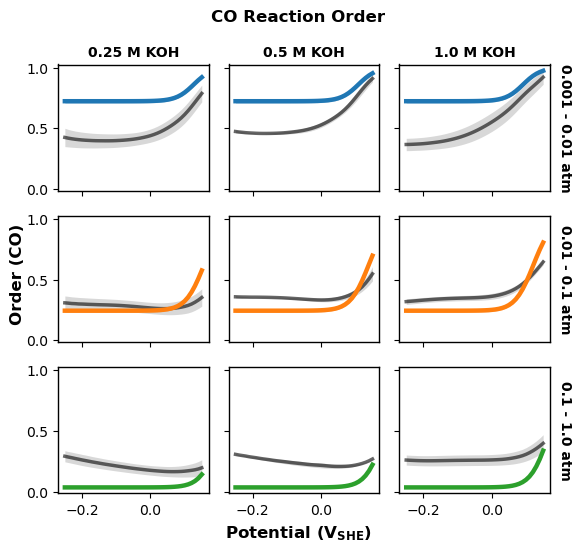

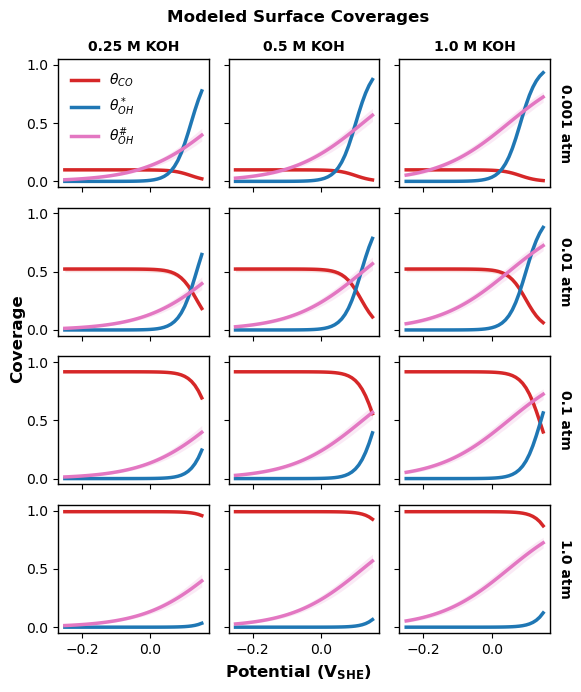

In [13]:
ppc_BF_PCT_Ag = plot_posteriors(trace_BF_PCT_Ag, BF_PCT_Ag)
plot_model_fits(trace_BF_PCT_Ag, ppc_BF_PCT_Ag); plot_coverages(trace_BF_PCT_Ag)

# BF LH PCT Ag

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,1,0.20,31
,3000,0,0.22,15
,3000,0,0.20,7
,3000,1,0.18,31


Computed from 4000 posterior samples and 1476 observations log-likelihood matrix.

         Estimate       SE
elpd_loo   476.45    55.21
p_loo        9.77        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     1476  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



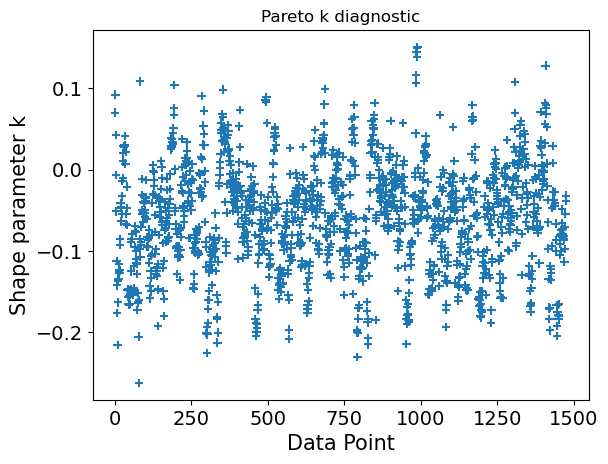

In [14]:
with pm.Model() as BF_LH_PCT_Ag:
    '''
    1. CO + * <-> CO* (QEA)
    2a. CO* + OH(q-1)# -> COOH* + # + (1-q)(e-) (RDS) (BF)
    2b. CO* + OH* -> COOH* + * (RDS) (LH)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Fast)
    4. OH- + * <-> OH* + (e-) (QEA)
    5. OH- + # <-> OH(q-1)# + (q)(e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.2) # at 0V_SHE
    deltaG5_0 = pm.Normal('deltaG5_0', mu=0.0, sigma=0.2) # at 0V_SHE
    beta_2 = pm.Beta('beta_2', alpha=5, beta=5)
    q = pm.Beta('q', alpha=1, beta=1)
    Gact2_BF_0 = pm.Normal('Gact2_BF_0', mu=0.7, sigma=0.2)
    Gact2_LH_0 = pm.Normal('Gact2_LH_0', mu=0.7, sigma=0.2)

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    deltaG5 = deltaG5_0 - q * E_in
    Gact2_BF = Gact2_BF_0 - beta_2 * (1.0 - q) * E_in
    Gact2_LH = Gact2_LH_0
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_K5 = -deltaG5/(kb_eV*T)
    log_k2_BF = np.log(kb_J*T/h) - Gact2_BF/(kb_eV*T)
    log_k2_LH = np.log(kb_J*T/h) - Gact2_LH/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH_Pd = log_K4 + np.log(C_KOH_in)
    term_OH_Ag = log_K5 + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_CO)
    log_theta_Pd = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH_Pd]), axis=0)
    log_theta_Ag = - pt.logsumexp(pt.stack([zeros, term_OH_Ag]), axis=0)
    log_theta_CO = term_CO + log_theta_Pd
    log_theta_OH_Pd = term_OH_Pd + log_theta_Pd
    log_theta_OH_Ag = term_OH_Ag + log_theta_Ag

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH_star = pm.Deterministic('theta_OH_star', pt.exp(log_theta_OH_Pd))
    theta_OH_pound = pm.Deterministic('theta_OH_pound', pt.exp(log_theta_OH_Ag))
    theta_empty_Pd = pm.Deterministic('theta_empty_Pd', pt.exp(log_theta_Pd))
    theta_empty_Ag = pm.Deterministic('theta_empty_Ag', pt.exp(log_theta_Ag))

    # Rate expression
    log_rate_BF = log_k2_BF + log_theta_CO + log_theta_OH_Ag + np.log(Ag_comp)
    log_rate_LH = log_k2_LH + log_theta_CO + log_theta_OH_Pd + np.log(1.0 - Ag_comp)
    log_rate = pt.logaddexp(log_rate_BF, log_rate_LH)
    rate = observables(log_rate) 

trace_BF_LH_PCT_Ag, loo_BF_LH_PCT_Ag = fit_and_evaluate(BF_LH_PCT_Ag)

             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG1_0  -0.119  0.001  -0.121   -0.116      0.000    0.000    2228.0    2384.0    1.0
deltaG4_0   0.081  0.002   0.077    0.085      0.000    0.000    2030.0    2429.0    1.0
deltaG5_0   0.012  0.003   0.007    0.017      0.000    0.000     877.0    1006.0    1.0
Gact2_BF_0  0.674  0.002   0.670    0.677      0.000    0.000     851.0     951.0    1.0
Gact2_LH_0  0.914  0.111   0.750    1.118      0.003    0.002    2022.0    1977.0    1.0
beta_2      0.030  0.010   0.012    0.049      0.000    0.000    1459.0    1823.0    1.0
q           0.243  0.010   0.225    0.260      0.000    0.000    1676.0    2132.0    1.0
sigma_rel   0.284  0.008   0.269    0.299      0.000    0.000    3216.0    3138.0    1.0
sigma_base  0.001  0.001   0.000    0.003      0.000    0.000    2992.0    1480.0    1.0
exponent    1.768  0.048   1.678    1.857      0.001    0.001    2110.0    2154.0    1.0


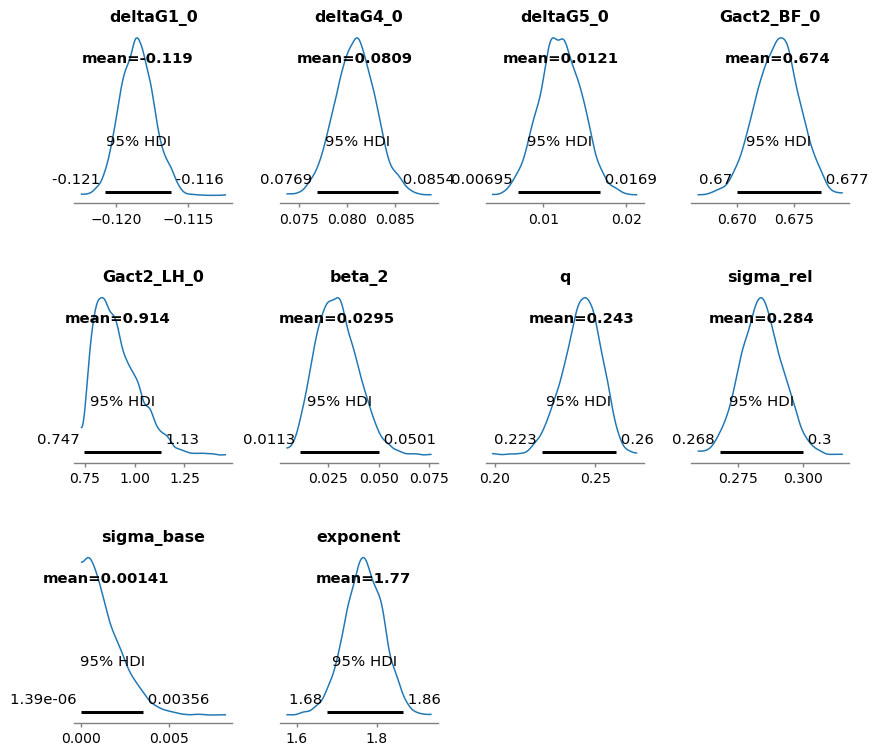

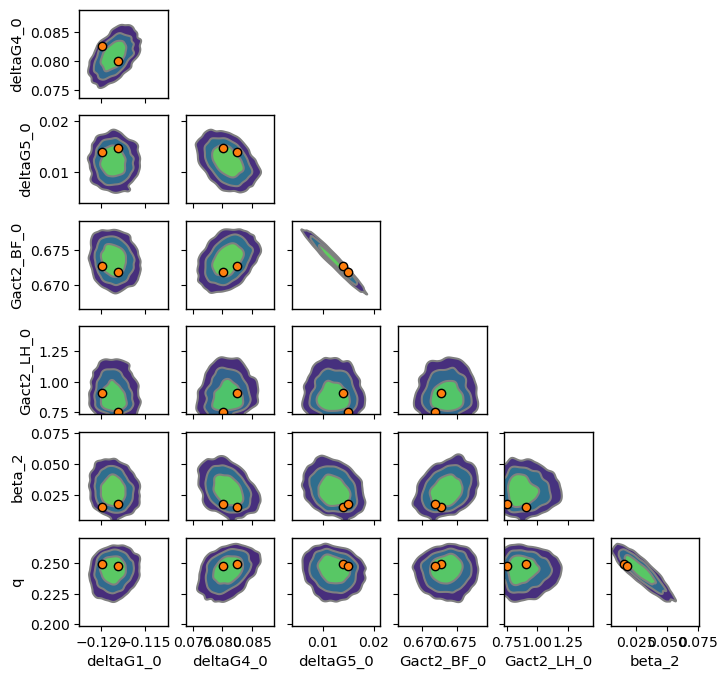

Sampling: [rate]


rate: 0.770


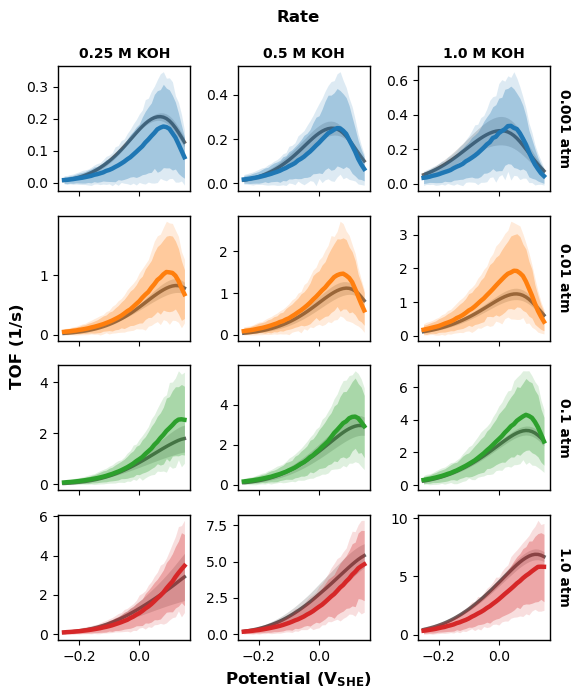

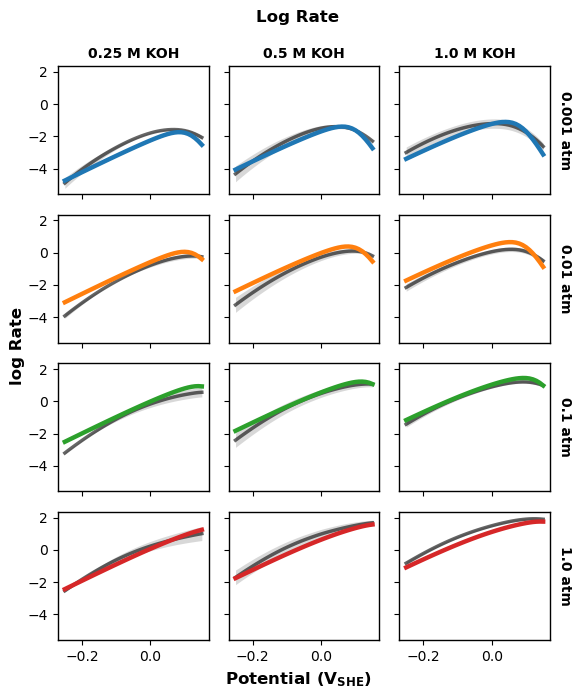

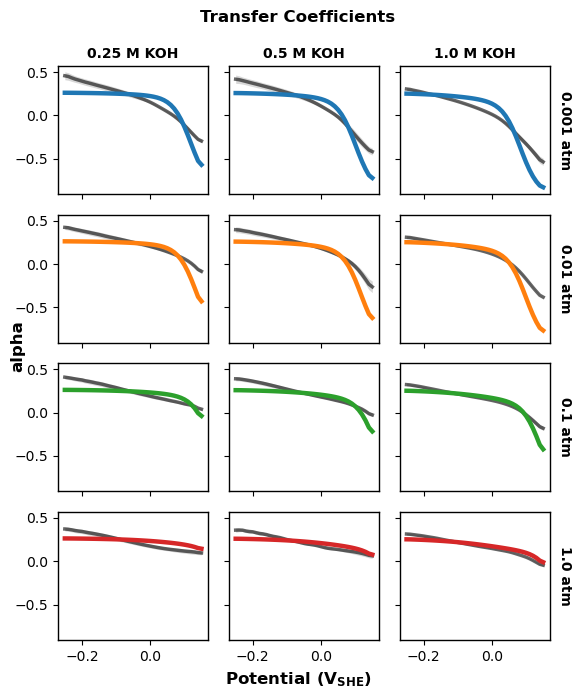

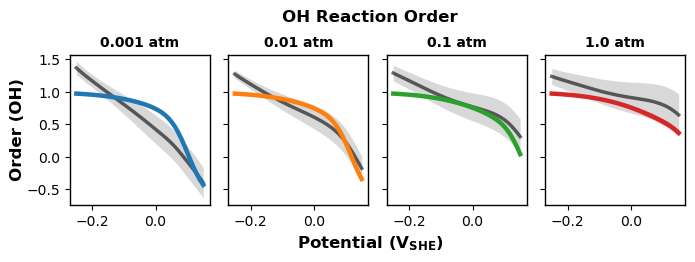

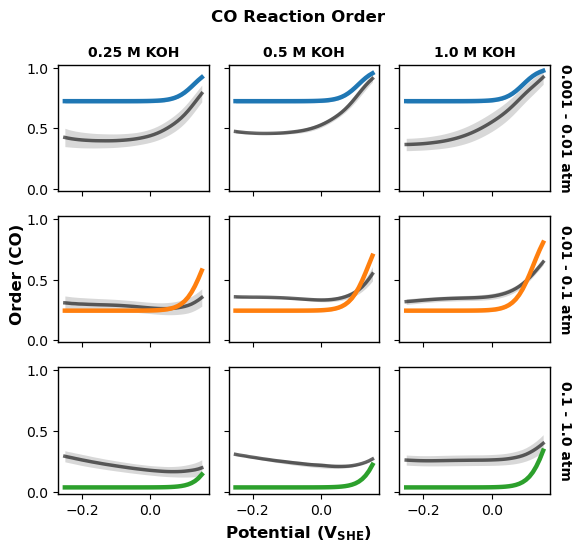

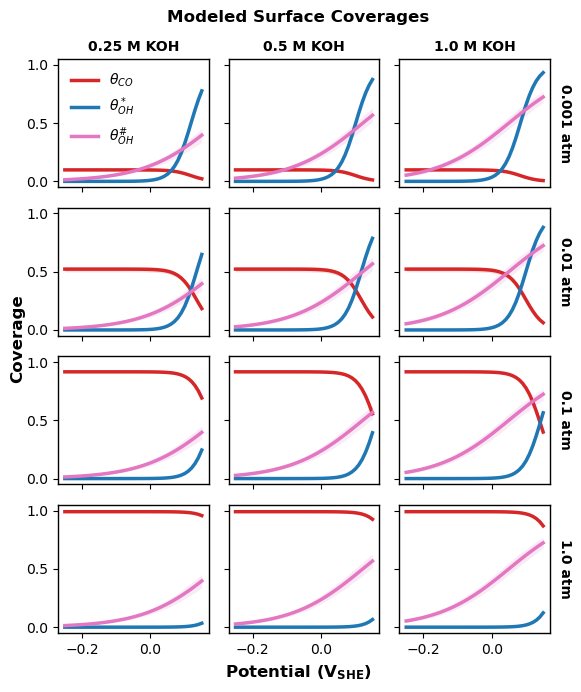

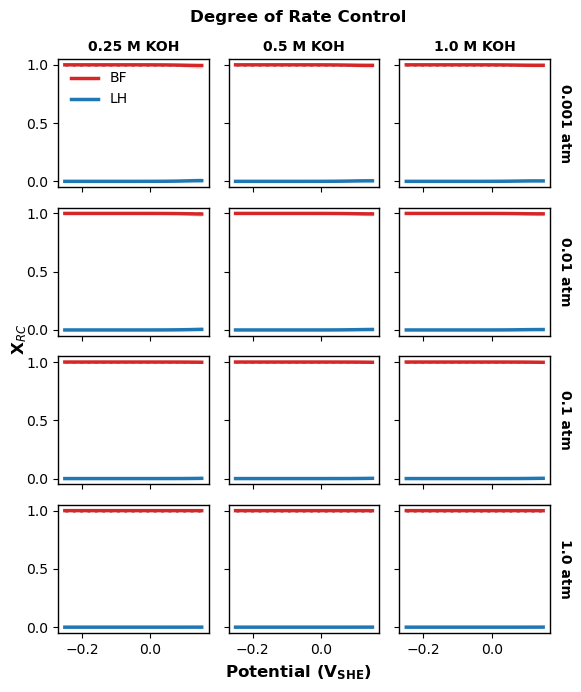

In [15]:
ppc_BF_LH_PCT_Ag = plot_posteriors(trace_BF_LH_PCT_Ag, BF_LH_PCT_Ag)
plot_model_fits(trace_BF_LH_PCT_Ag, ppc_BF_LH_PCT_Ag); plot_coverages(trace_BF_LH_PCT_Ag)
plot_drc(BF_LH_PCT_Ag, trace_BF_LH_PCT_Ag, perturb_vars=['Gact2_BF_0', 'Gact2_LH_0'], perturb_labels=['BF', 'LH'])

# BF ER PCT Ag

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.13,31
,3000,0,0.16,31
,3000,0,0.15,63
,3000,0,0.15,31


Computed from 4000 posterior samples and 1476 observations log-likelihood matrix.

         Estimate       SE
elpd_loo   488.16    56.82
p_loo       13.39        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     1476  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



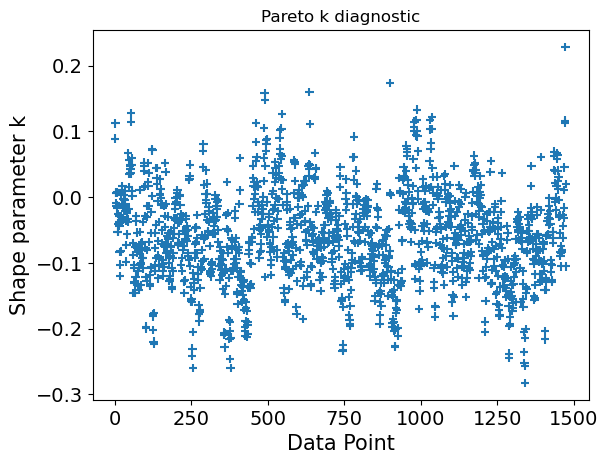

In [16]:
with pm.Model() as BF_ER_PCT_Ag:
    '''
    1. CO + * <-> CO* (QEA)
    2a. CO* + OH(q-1)# -> COOH* + # + (1-q)(e-) (RDS) (BF)
    2b. CO* + OH- -> COOH* + (e-) (RDS) (ER)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Fast)
    4. OH- + * <-> OH* + (e-) (QEA)
    5. OH- + # <-> OH(q-1)# + (q)(e-) (QEA)
    '''
     # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.2) # at 0V_SHE
    deltaG5_0 = pm.Normal('deltaG5_0', mu=0.0, sigma=0.2) # at 0V_SHE
    beta_2_BF = pm.Beta('beta_2_BF', alpha=5, beta=5)
    beta_2_ER = pm.Beta('beta_2_ER', alpha=5, beta=5)
    q = pm.Beta('q', alpha=1, beta=1)
    Gact2_BF_0 = pm.Normal('Gact2_BF_0', mu=0.7, sigma=0.2)
    Gact2_ER_0 = pm.Normal('Gact2_ER_0', mu=0.7, sigma=0.2)

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    deltaG5 = deltaG5_0 - q * E_in
    Gact2_BF = Gact2_BF_0 - beta_2_BF * (1.0 - q) * E_in
    Gact2_ER = Gact2_ER_0 - beta_2_ER * E_in
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_K5 = -deltaG5/(kb_eV*T)
    log_k2_BF = np.log(kb_J*T/h) - Gact2_BF/(kb_eV*T)
    log_k2_ER = np.log(kb_J*T/h) - Gact2_ER/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH_Pd = log_K4 + np.log(C_KOH_in)
    term_OH_Ag = log_K5 + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_CO)
    log_theta_Pd = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH_Pd]), axis=0)
    log_theta_Ag = - pt.logsumexp(pt.stack([zeros, term_OH_Ag]), axis=0)
    log_theta_CO = term_CO + log_theta_Pd
    log_theta_OH_Pd = term_OH_Pd + log_theta_Pd
    log_theta_OH_Ag = term_OH_Ag + log_theta_Ag

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH_star = pm.Deterministic('theta_OH_star', pt.exp(log_theta_OH_Pd))
    theta_OH_pound = pm.Deterministic('theta_OH_pound', pt.exp(log_theta_OH_Ag))
    theta_empty_Pd = pm.Deterministic('theta_empty_Pd', pt.exp(log_theta_Pd))
    theta_empty_Ag = pm.Deterministic('theta_empty_Ag', pt.exp(log_theta_Ag))

    # Rate expression
    log_rate_BF = log_k2_BF + log_theta_CO + log_theta_OH_Ag + np.log(Ag_comp)
    log_rate_ER = log_k2_ER + log_theta_CO + np.log(C_KOH_in)
    log_rate = pt.logaddexp(log_rate_BF, log_rate_ER)
    rate = observables(log_rate) 

trace_BF_ER_PCT_Ag, loo_BF_ER_PCT_Ag = fit_and_evaluate(BF_ER_PCT_Ag, target_accept=0.95)

             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG1_0  -0.120  0.001  -0.122   -0.118      0.000    0.000    1754.0    2493.0   1.00
deltaG4_0   0.082  0.002   0.078    0.086      0.000    0.000    1848.0    2415.0   1.00
deltaG5_0  -0.064  0.018  -0.098   -0.031      0.001    0.001     533.0     617.0   1.02
Gact2_BF_0  0.726  0.006   0.716    0.736      0.000    0.000     529.0     824.0   1.01
Gact2_ER_0  0.726  0.002   0.722    0.730      0.000    0.000     603.0     931.0   1.01
beta_2_BF   0.103  0.081   0.007    0.248      0.004    0.005     628.0     627.0   1.02
beta_2_ER   0.202  0.006   0.190    0.214      0.000    0.000    1681.0    1848.0   1.00
q           0.534  0.095   0.370    0.718      0.004    0.005     537.0     582.0   1.02
sigma_rel   0.289  0.008   0.274    0.305      0.000    0.000    3735.0    3219.0   1.00
sigma_base  0.001  0.001   0.000    0.003      0.000    0.000    2641.0    1588.0   1.00
exponent    1.848  0.

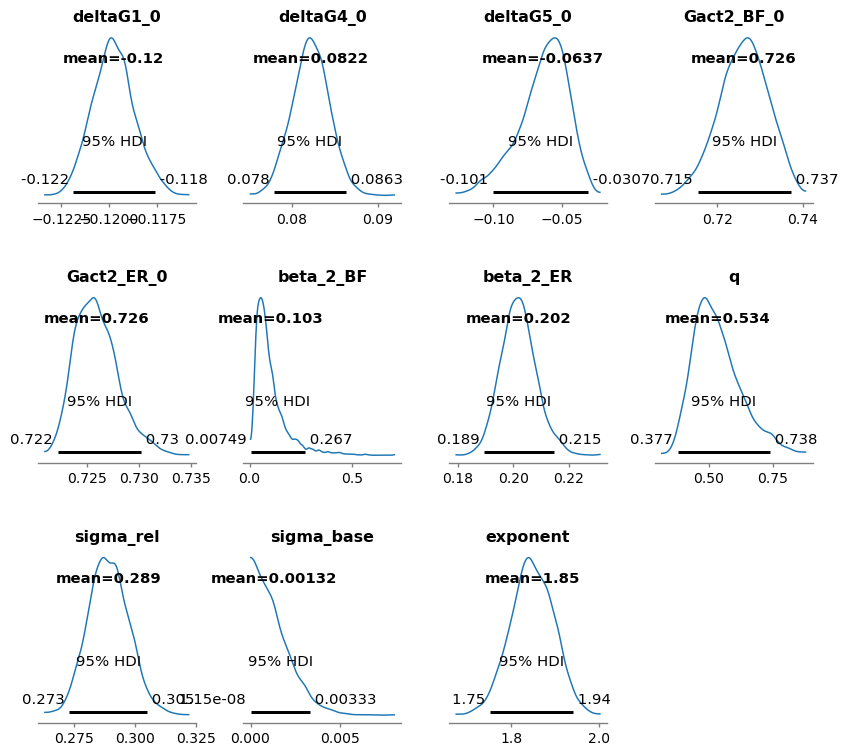

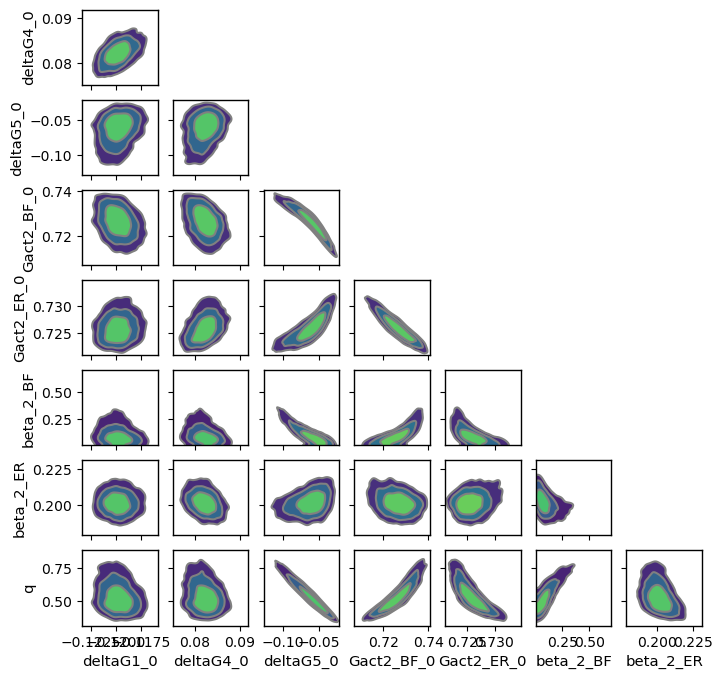

Sampling: [rate]


rate: 0.756


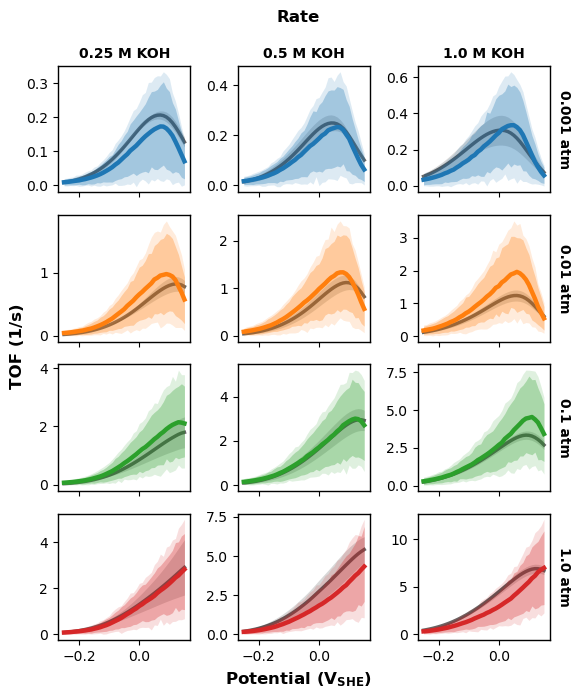

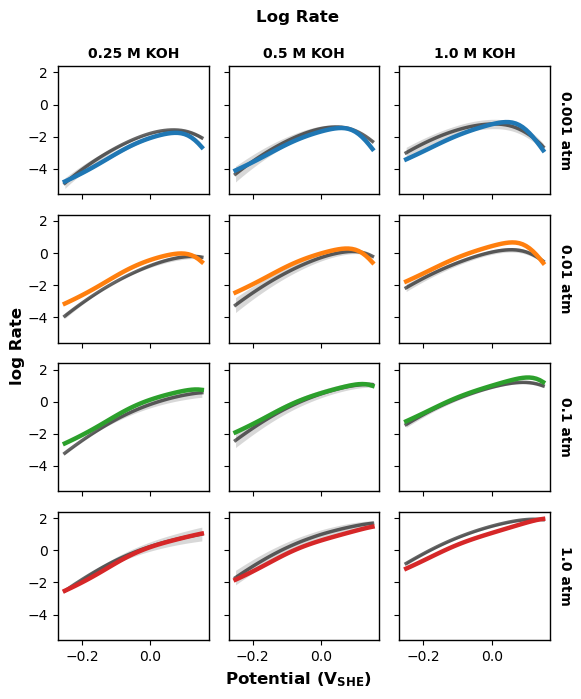

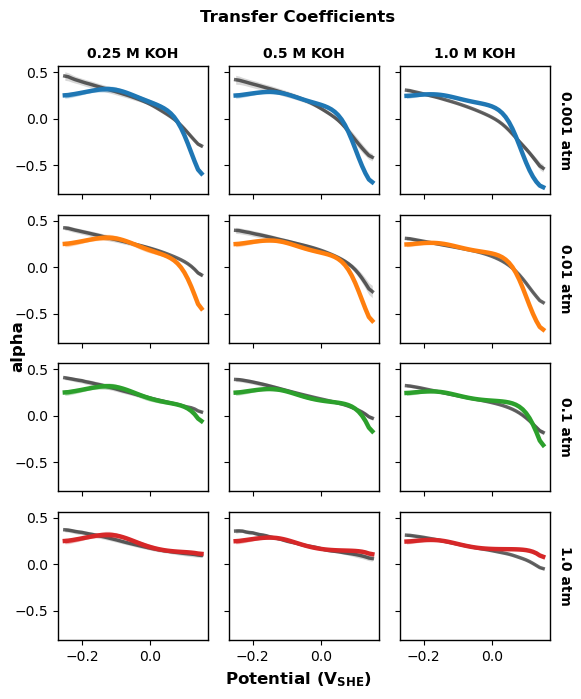

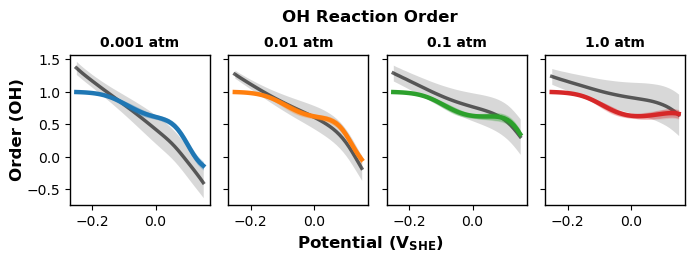

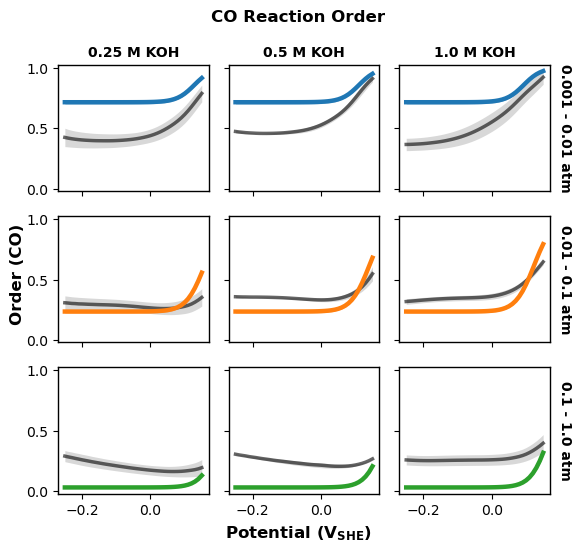

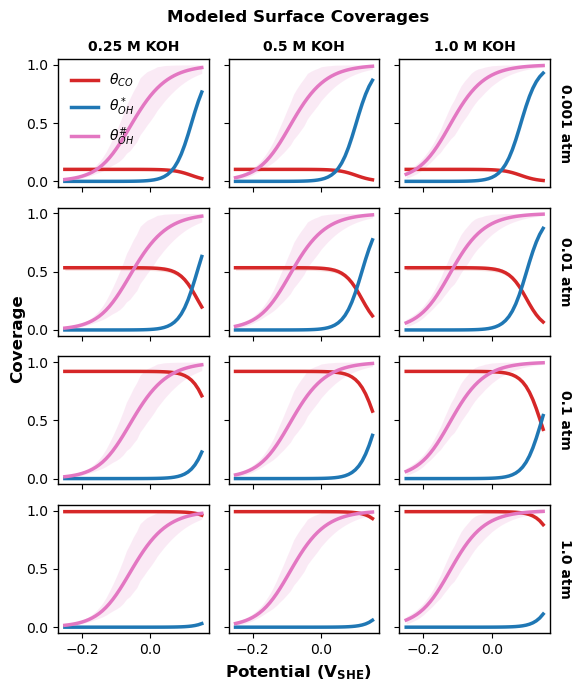

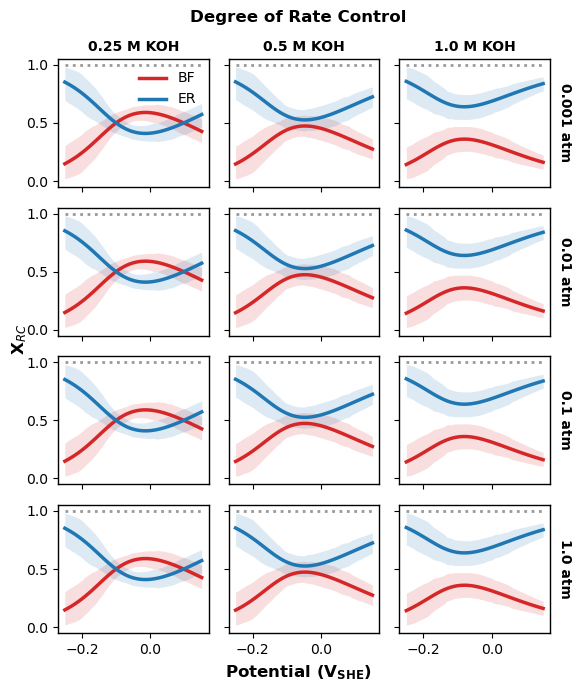

In [17]:
ppc_BF_ER_PCT_Ag = plot_posteriors(trace_BF_ER_PCT_Ag, BF_ER_PCT_Ag)
plot_model_fits(trace_BF_ER_PCT_Ag, ppc_BF_ER_PCT_Ag); plot_coverages(trace_BF_ER_PCT_Ag)
plot_drc(BF_ER_PCT_Ag, trace_BF_ER_PCT_Ag, perturb_vars=['Gact2_BF_0', 'Gact2_ER_0'], perturb_labels=['BF', 'ER'])

# BF LH ER PCT Ag

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.07,63
,3000,0,0.07,63
,3000,0,0.08,63
,3000,0,0.07,127


Computed from 4000 posterior samples and 1476 observations log-likelihood matrix.

         Estimate       SE
elpd_loo   489.55    56.79
p_loo       14.02        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     1476  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



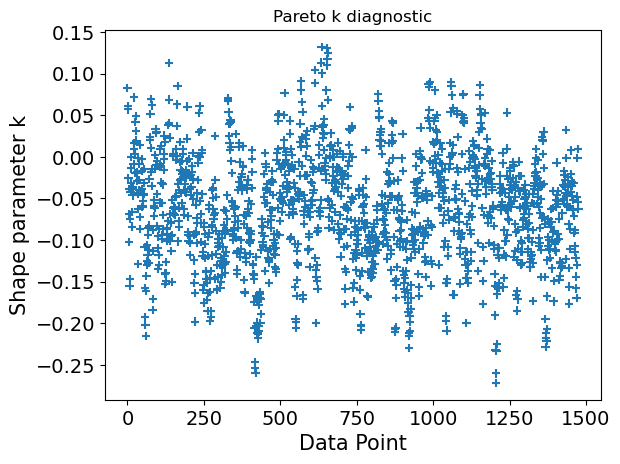

In [18]:
with pm.Model() as BF_LH_ER_PCT_Ag:
    '''
    1. CO + * <-> CO* (QEA)
    2a. CO* + OH(q-1)# -> COOH* + # + (1-q)(e-) (RDS) (BF)
    2b. CO* + OH* -> COOH* + * (RDS) (LH)
    2c. CO* + OH- -> COOH* + (e-) (RDS) (ER)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Fast)
    4. OH- + * <-> OH* + (e-) (QEA)
    5. OH- + # <-> OH(q-1)# + (q)(e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.2) # at 0V_SHE
    deltaG5_0 = pm.Normal('deltaG5_0', mu=0.0, sigma=0.2) # at 0V_SHE
    beta_2_BF = pm.Beta('beta_2_BF', alpha=5, beta=5)
    beta_2_ER = pm.Beta('beta_2_ER', alpha=5, beta=5)
    q = pm.Beta('q', alpha=1, beta=1)
    Gact2_BF_0 = pm.Normal('Gact2_BF_0', mu=0.7, sigma=0.2)
    Gact2_LH_0 = pm.Normal('Gact2_LH_0', mu=0.7, sigma=0.2)
    Gact2_ER_0 = pm.Normal('Gact2_ER_0', mu=0.7, sigma=0.2) # at 0V_SHE

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    deltaG5 = deltaG5_0 - q * E_in
    Gact2_BF = Gact2_BF_0 - beta_2_BF * (1.0 - q) * E_in
    Gact2_LH = Gact2_LH_0
    Gact2_ER = Gact2_ER_0 - beta_2_ER * E_in
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_K5 = -deltaG5/(kb_eV*T)
    log_k2_BF = np.log(kb_J*T/h) - Gact2_BF/(kb_eV*T)
    log_k2_LH = np.log(kb_J*T/h) - Gact2_LH/(kb_eV*T)
    log_k2_ER = np.log(kb_J*T/h) - Gact2_ER/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH_Pd = log_K4 + np.log(C_KOH_in)
    term_OH_Ag = log_K5 + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_CO)
    log_theta_Pd = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH_Pd]), axis=0)
    log_theta_Ag = - pt.logsumexp(pt.stack([zeros, term_OH_Ag]), axis=0)
    log_theta_CO = term_CO + log_theta_Pd
    log_theta_OH_Pd = term_OH_Pd + log_theta_Pd
    log_theta_OH_Ag = term_OH_Ag + log_theta_Ag

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH_star = pm.Deterministic('theta_OH_star', pt.exp(log_theta_OH_Pd))
    theta_OH_pound = pm.Deterministic('theta_OH_pound', pt.exp(log_theta_OH_Ag))
    theta_empty_Pd = pm.Deterministic('theta_empty_Pd', pt.exp(log_theta_Pd))
    theta_empty_Ag = pm.Deterministic('theta_empty_Ag', pt.exp(log_theta_Ag))

    # Rate expression
    log_rate_BF = log_k2_BF + log_theta_CO + log_theta_OH_Ag + np.log(Ag_comp)
    log_rate_LH = log_k2_LH + log_theta_CO + log_theta_OH_Pd + np.log(1.0 - Ag_comp)
    log_rate_ER = log_k2_ER + log_theta_CO + np.log(C_KOH_in)
    log_rate = pt.logsumexp(pt.stack([log_rate_BF, log_rate_LH, log_rate_ER]), axis=0)
    rate = observables(log_rate) 

trace_BF_LH_ER_PCT_Ag, loo_BF_LH_ER_PCT_Ag = fit_and_evaluate(BF_LH_ER_PCT_Ag, target_accept=0.99)

             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG1_0  -0.120  0.001  -0.122   -0.118      0.000    0.000    1987.0    2483.0   1.00
deltaG4_0   0.078  0.003   0.072    0.084      0.000    0.000     472.0     927.0   1.00
deltaG5_0  -0.078  0.020  -0.117   -0.044      0.001    0.000     419.0     959.0   1.01
Gact2_BF_0  0.731  0.006   0.721    0.741      0.000    0.000     422.0     959.0   1.00
Gact2_LH_0  0.754  0.064   0.708    0.901      0.005    0.007     312.0     246.0   1.01
Gact2_ER_0  0.724  0.002   0.721    0.728      0.000    0.000     449.0     923.0   1.01
beta_2_BF   0.134  0.106   0.014    0.324      0.004    0.005     591.0    1097.0   1.00
beta_2_ER   0.202  0.006   0.191    0.213      0.000    0.000    2559.0    2286.0   1.00
q           0.623  0.117   0.429    0.856      0.006    0.003     410.0     879.0   1.01
sigma_rel   0.289  0.008   0.274    0.304      0.000    0.000    3424.0    2946.0   1.00
sigma_base  0.001  0.

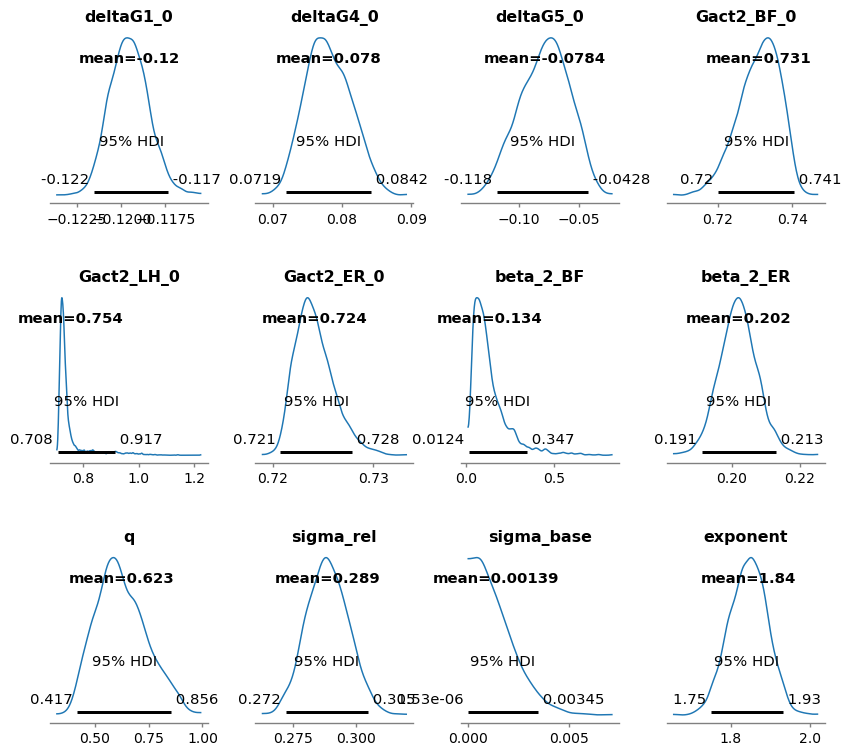

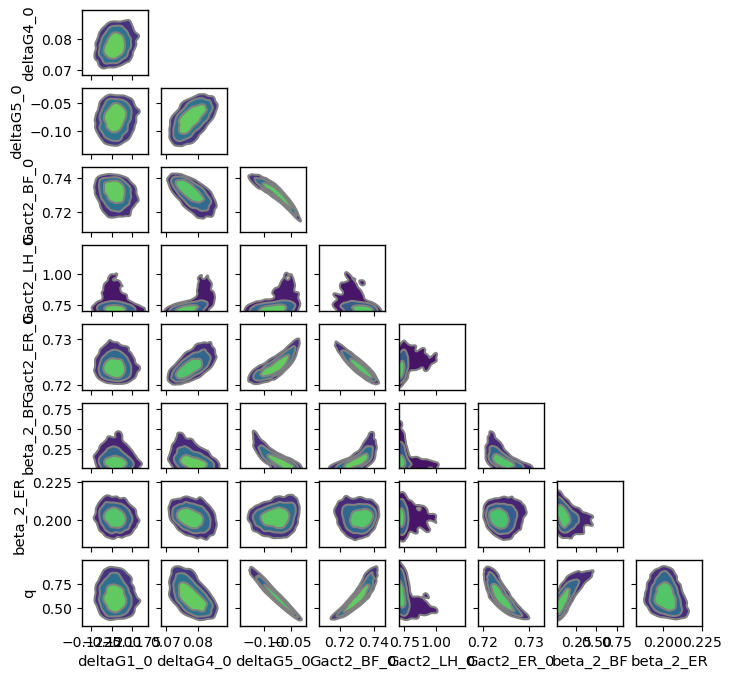

Sampling: [rate]


rate: 0.760


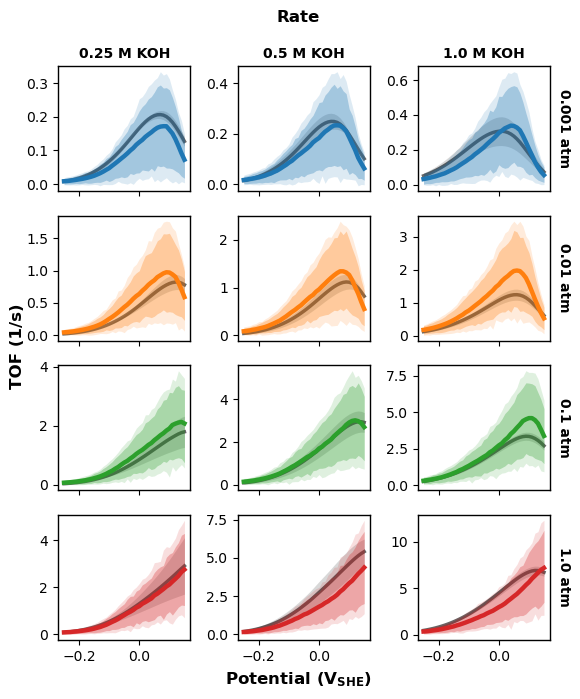

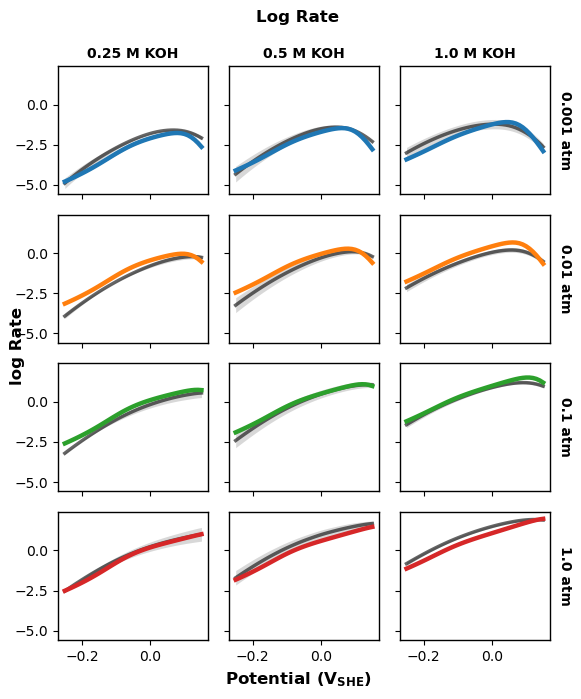

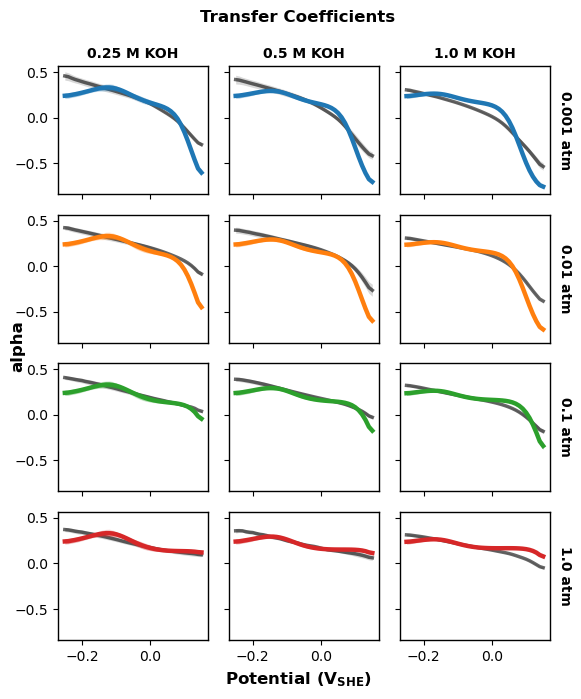

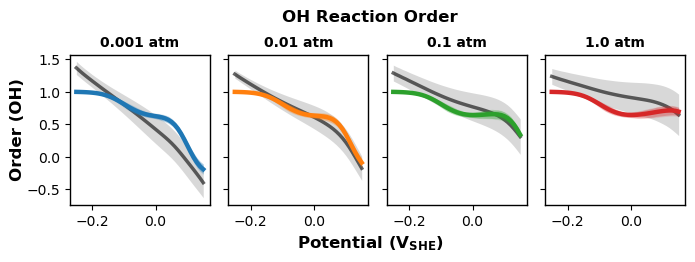

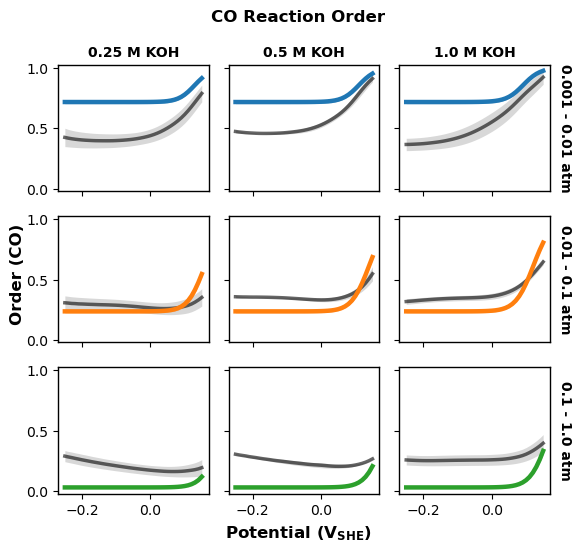

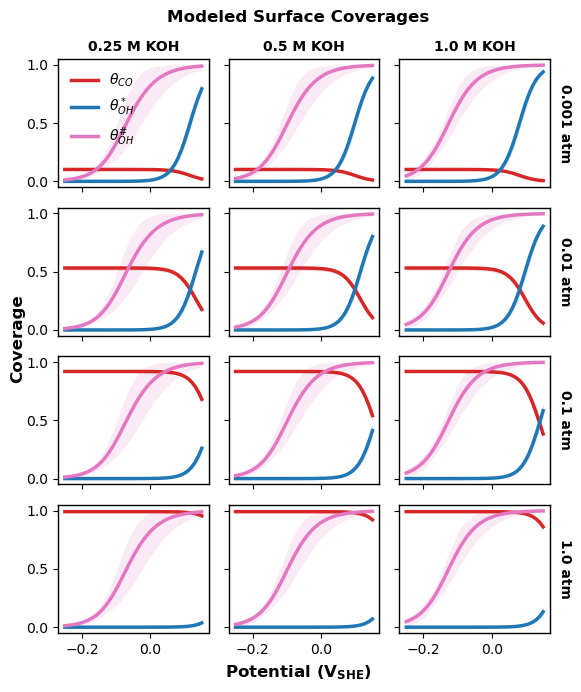

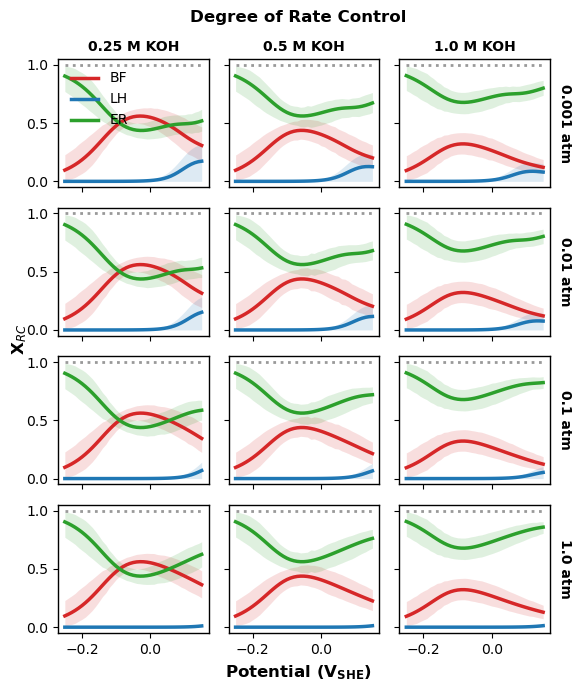

In [19]:
ppc_BF_LH_ER_PCT_Ag = plot_posteriors(trace_BF_LH_ER_PCT_Ag, BF_LH_ER_PCT_Ag)
plot_model_fits(trace_BF_LH_ER_PCT_Ag, ppc_BF_LH_ER_PCT_Ag); plot_coverages(trace_BF_LH_ER_PCT_Ag)
plot_drc(BF_LH_ER_PCT_Ag, trace_BF_LH_ER_PCT_Ag, perturb_vars=['Gact2_BF_0', 'Gact2_LH_0', 'Gact2_ER_0'], perturb_labels=['BF', 'LH', 'ER'])

# CO BF PCT Ag 

In [20]:
with pm.Model() as CO_BF_PCT_Ag:
    '''
    1. CO + * <-> CO* (SSA)
    2. CO* + OH(q-1)# -> COOH* + # + (1-q)(e-) (SSA)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Fast)
    4. OH- + * <-> OH* + (e-) (QEA)
    5. OH- + # <-> OH(q-1)# + (q)(e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.2) # at 0V_SHE
    deltaG5_0 = pm.Normal('deltaG5_0', mu=0.0, sigma=0.2) # at 0V_SHE
    beta_2 = pm.Beta('beta_2', alpha=5, beta=5)
    q = pm.Beta('q', alpha=1, beta=1)
    Gact1_0 = pm.Normal('Gact1_0', mu=0.7, sigma=0.2)
    Gact2_0 = pm.Normal('Gact2_0', mu=0.7, sigma=0.2)

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    deltaG5 = deltaG5_0 - q * E_in
    Gact1 = Gact1_0
    Gact2 = Gact2_0 - beta_2 * (1.0 - q) * E_in
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_K5 = -deltaG5/(kb_eV*T)
    log_k1 = np.log(kb_J*T/h) - Gact1/(kb_eV*T)
    log_k2 = np.log(kb_J*T/h) - Gact2/(kb_eV*T)

    term_OH_Ag = log_K5 + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_OH_Ag)
    log_theta_Ag = -pt.logsumexp(pt.stack([zeros, term_OH_Ag]), axis=0)
    log_theta_OH_Ag = term_OH_Ag + log_theta_Ag
    term_OH_Pd = log_K4 + np.log(C_KOH_in)
    log_A_Pd = pt.logsumexp(pt.stack([zeros, term_OH_Pd]), axis=0) 
    log_k1_PCO = log_k1 + np.log(P_CO_in)                    
    log_k_minus_1 = log_k1 - log_K1                                
    log_k_BF_app = log_k2 + log_theta_OH_Ag + np.log(Ag_comp)     
    log_denom_Pd = pt.logsumexp(pt.stack([log_k1_PCO, log_A_Pd + log_k_minus_1, log_A_Pd + log_k_BF_app]), axis=0)

    # Calculate final coverages exactly
    log_theta_CO = log_k1_PCO - log_denom_Pd
    log_theta_Pd = pt.logsumexp(pt.stack([log_k_minus_1 + zeros, log_k_BF_app]), axis=0) - log_denom_Pd
    log_theta_OH_Pd = term_OH_Pd + log_theta_Pd

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH_star = pm.Deterministic('theta_OH_star', pt.exp(log_theta_OH_Pd))
    theta_OH_pound = pm.Deterministic('theta_OH_pound', pt.exp(log_theta_OH_Ag))
    theta_empty_Pd = pm.Deterministic('theta_empty_Pd', pt.exp(log_theta_Pd))
    theta_empty_Ag = pm.Deterministic('theta_empty_Ag', pt.exp(log_theta_Ag))

    # Rate expression
    log_rate = log_k_BF_app + log_theta_CO
    rate = observables(log_rate) 

# trace_CO_BF_PCT_Ag, loo_CO_BF_PCT_Ag = fit_and_evaluate(CO_BF_PCT_Ag)

In [21]:
# ppc_CO_BF_LH_PCT_Ag = plot_posteriors(trace_CO_BF_PCT_Ag, CO_BF_PCT_Ag)#
# plot_model_fits(trace_CO_BF_PCT_Ag, ppc_CO_BF_LH_PCT_Ag); plot_coverages(trace_CO_BF_PCT_Ag)
# plot_drc(CO_BF_PCT_Ag, trace_CO_BF_PCT_Ag, perturb_vars=['Gact2_0', 'Gact1_0'], perturb_labels=['BF', 'CO ads'])

# OH Ag BF PCT Ag

In [22]:
with pm.Model() as OH_Ag_BF_PCT_Ag:
    '''
    1. CO + * <-> CO* (QEA)
    2. CO* + OH(q-1)# -> COOH* + # + (1-q)(e-) (SSA)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Fast)
    4. OH- + * <-> OH* + (e-) (QEA)
    5. OH- + # <-> OH(q-1)# + (q)(e-) (SSA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.2) # at 0V_SHE
    deltaG5_0 = pm.Normal('deltaG5_0', mu=0.0, sigma=0.2) # at 0V_SHE
    beta_2 = pm.Beta('beta_2', alpha=5, beta=5)
    beta_5 = pm.Beta('beta_5', alpha=5, beta=5)
    q = pm.Beta('q', alpha=10, beta=10)
    Gact2_0 = pm.Normal('Gact2_0', mu=0.7, sigma=0.2)
    Gact5_0 = pm.Normal('Gact5_0', mu=0.7, sigma=0.2)

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    deltaG5 = deltaG5_0 - q * E_in
    Gact2 = Gact2_0 - beta_2 * (1.0 - q) * E_in
    Gact5 = Gact5_0 - beta_5 * q * E_in
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_K5 = -deltaG5/(kb_eV*T)
    log_k2 = np.log(kb_J*T/h) - Gact2/(kb_eV*T)
    log_k5 = np.log(kb_J*T/h) - Gact5/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH_Pd = log_K4 + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_CO)
    log_theta_Pd = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH_Pd]), axis=0)
    log_theta_CO = term_CO + log_theta_Pd
    log_theta_OH_Pd = term_OH_Pd + log_theta_Pd
    log_k5_CKOH = log_k5 + np.log(C_KOH_in)
    log_k_minus_5 = log_k5 - log_K5
    log_k2_theta_CO = log_k2 + log_theta_CO
    log_den_Ag = pt.logsumexp(pt.stack([log_k5_CKOH, log_k_minus_5, log_k2_theta_CO]), axis=0)
    log_theta_OH_Ag = log_k5_CKOH - log_den_Ag
    log_num_empty_Ag = pt.logsumexp(pt.stack([log_k_minus_5, log_k2_theta_CO]), axis=0)
    log_theta_empty_Ag = log_num_empty_Ag - log_den_Ag

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH_star = pm.Deterministic('theta_OH_star', pt.exp(log_theta_OH_Pd))
    theta_OH_pound = pm.Deterministic('theta_OH_pound', pt.exp(log_theta_OH_Ag))
    theta_empty_Pd = pm.Deterministic('theta_empty_Pd', pt.exp(log_theta_Pd))
    theta_empty_Ag = pm.Deterministic('theta_empty_Ag', pt.exp(log_theta_empty_Ag))

    # Rate expression 
    log_rate = log_k2 + log_theta_CO + log_theta_OH_Ag + np.log(Ag_comp)
    rate = observables(log_rate)
    
# trace_OH_Ag_BF_PCT_Ag, loo_OH_Ag_BF_PCT_Ag = fit_and_evaluate(OH_Ag_BF_PCT_Ag)

In [23]:
# ppc_OH_Ag_BF_PCT_Ag = plot_posteriors(trace_OH_Ag_BF_PCT_Ag, OH_Ag_BF_PCT_Ag)
# plot_model_fits(trace_OH_Ag_BF_PCT_Ag, ppc_OH_Ag_BF_PCT_Ag); plot_coverages(trace_OH_Ag_BF_PCT_Ag)
# plot_drc(OH_Ag_BF_PCT_Ag, trace_OH_Ag_BF_PCT_Ag, perturb_vars=['Gact2_0', 'Gact5_0'], perturb_labels=['BF', 'OH Ag ads'])

# BF LH PCT Ag Pd

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.25,15
,3000,0,0.25,31
,3000,0,0.22,7
,3000,0,0.24,15


Computed from 4000 posterior samples and 1476 observations log-likelihood matrix.

         Estimate       SE
elpd_loo   543.20    56.91
p_loo        9.35        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     1476  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



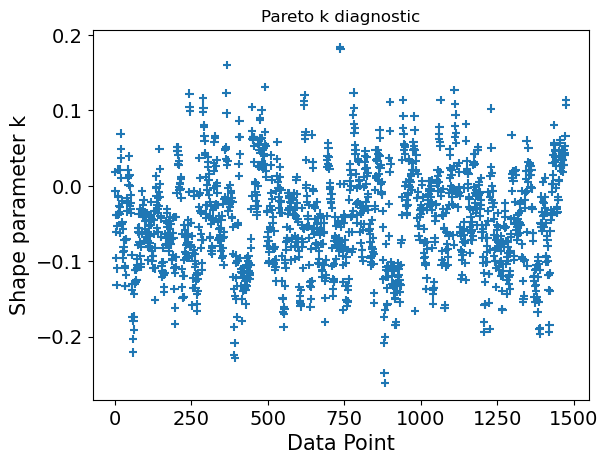

In [37]:
with pm.Model() as BF_LH_PCT_Ag_Pd:
    '''
    1. CO + * <-> CO* (QEA)
    2a. CO* + OH(q5-1)# -> COOH* + # + (1-q5)(e-) (RDS) (BF)
    2b. CO* + OH(q4-1)* -> COOH* + * + (1-q4)(e-) (RDS) (LH)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Fast)
    4. OH- + * <-> OH(q4-1)* + (q4)(e-) (QEA)
    5. OH- + # <-> OH(q5-1)# + (q5)(e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.2) # at 0V_SHE
    deltaG5_0 = pm.Normal('deltaG5_0', mu=0.0, sigma=0.2) # at 0V_SHE
    beta_2_BF = pm.Beta('beta_2_BF', alpha=5, beta=5)
    # beta_2_LH = pm.Beta('beta_2_LH', alpha=5, beta=5)
    q4 = pm.Beta('q4', alpha=10, beta=1)
    q5 = pm.Beta('q5', alpha=1, beta=1)
    Gact2_BF_0 = pm.Normal('Gact2_BF_0', mu=0.7, sigma=0.2)
    # Gact2_LH_0 = pm.Normal('Gact2_LH_0', mu=0.7, sigma=0.2)

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - q4 * E_in
    deltaG5 = deltaG5_0 - q5 * E_in
    Gact2_BF = Gact2_BF_0 - beta_2_BF * (1.0 - q5) * E_in
    # Gact2_LH = Gact2_LH_0 - beta_2_LH * (1.0 - q4) * E_in
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_K5 = -deltaG5/(kb_eV*T)
    log_k2_BF = np.log(kb_J*T/h) - Gact2_BF/(kb_eV*T)
    # log_k2_LH = np.log(kb_J*T/h) - Gact2_LH/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH_Pd = log_K4 + np.log(C_KOH_in)
    term_OH_Ag = log_K5 + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_CO)
    log_theta_Pd = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH_Pd]), axis=0)
    log_theta_Ag = - pt.logsumexp(pt.stack([zeros, term_OH_Ag]), axis=0)
    log_theta_CO = term_CO + log_theta_Pd
    log_theta_OH_Pd = term_OH_Pd + log_theta_Pd
    log_theta_OH_Ag = term_OH_Ag + log_theta_Ag

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH_star = pm.Deterministic('theta_OH_star', pt.exp(log_theta_OH_Pd))
    theta_OH_pound = pm.Deterministic('theta_OH_pound', pt.exp(log_theta_OH_Ag))
    theta_empty_Pd = pm.Deterministic('theta_empty_Pd', pt.exp(log_theta_Pd))
    theta_empty_Ag = pm.Deterministic('theta_empty_Ag', pt.exp(log_theta_Ag))

    # Rate expression
    log_rate_BF = log_k2_BF + log_theta_CO + log_theta_OH_Ag + np.log(Ag_comp)
    # log_rate_LH = log_k2_LH + log_theta_CO + log_theta_OH_Pd + np.log(1.0 - Ag_comp)
    # log_rate = pt.logaddexp(log_rate_BF, log_rate_LH)
    rate = observables(log_rate_BF) 

trace_BF_LH_PCT_Ag_Pd, loo_BF_LH_PCT_Ag_Pd = fit_and_evaluate(BF_LH_PCT_Ag_Pd)

             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG1_0  -0.125  0.001  -0.127   -0.122      0.000    0.000    2552.0    2738.0    1.0
deltaG4_0   0.018  0.004   0.011    0.026      0.000    0.000    1740.0    2047.0    1.0
deltaG5_0   0.016  0.002   0.011    0.020      0.000    0.000    1436.0    1512.0    1.0
Gact2_BF_0  0.670  0.002   0.667    0.674      0.000    0.000    1419.0    1615.0    1.0
beta_2_BF   0.020  0.008   0.006    0.034      0.000    0.000    2067.0    2175.0    1.0
q4          0.579  0.026   0.534    0.631      0.001    0.000    1850.0    2068.0    1.0
q5          0.259  0.008   0.244    0.272      0.000    0.000    2260.0    2142.0    1.0
sigma_rel   0.277  0.008   0.262    0.292      0.000    0.000    4671.0    3332.0    1.0
sigma_base  0.001  0.001   0.000    0.003      0.000    0.000    3178.0    1845.0    1.0
exponent    1.846  0.044   1.755    1.921      0.001    0.001    3021.0    2745.0    1.0


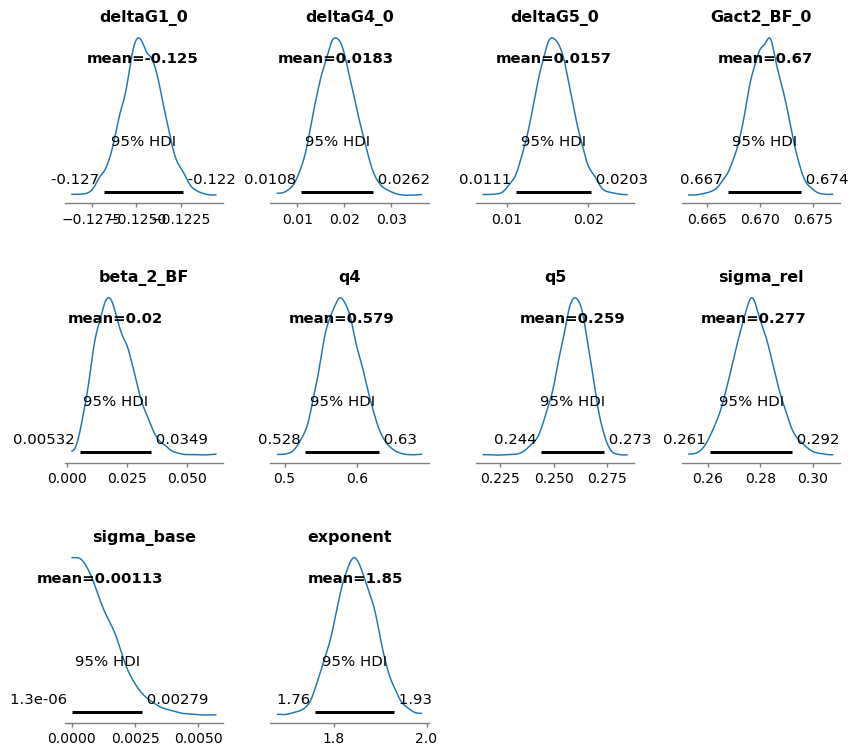

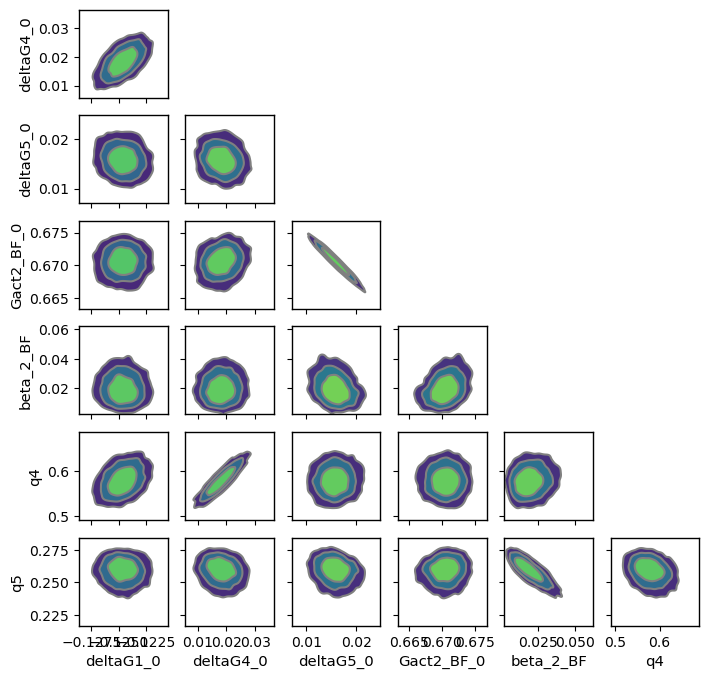

Sampling: [rate]


rate: 0.781


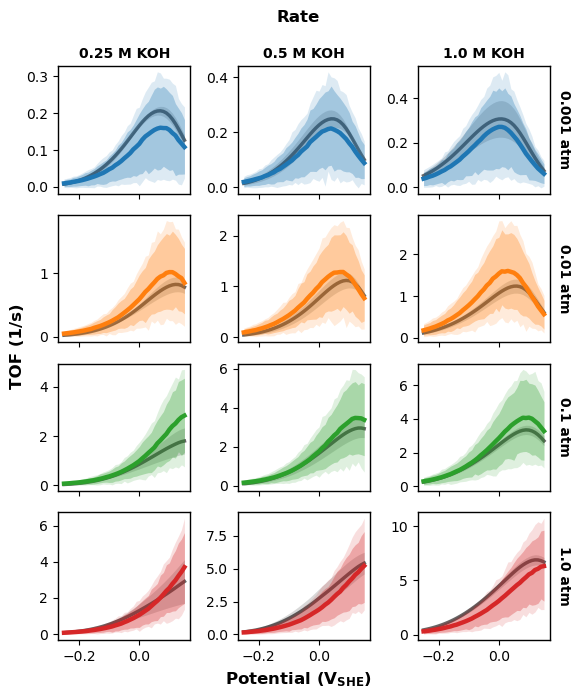

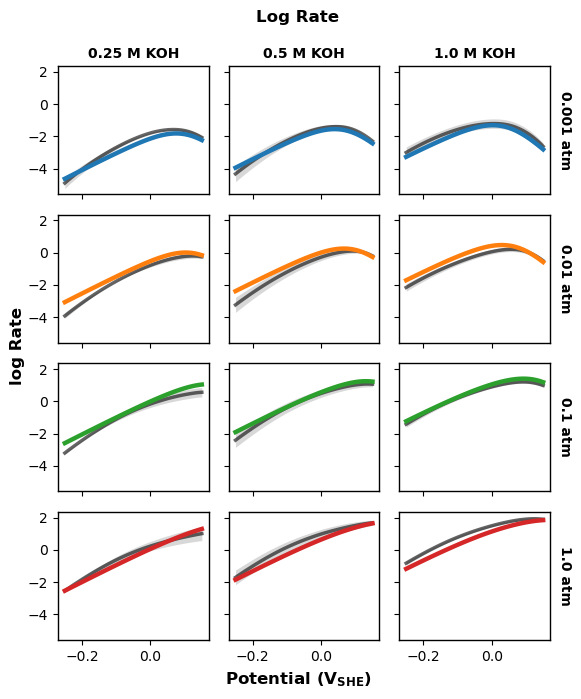

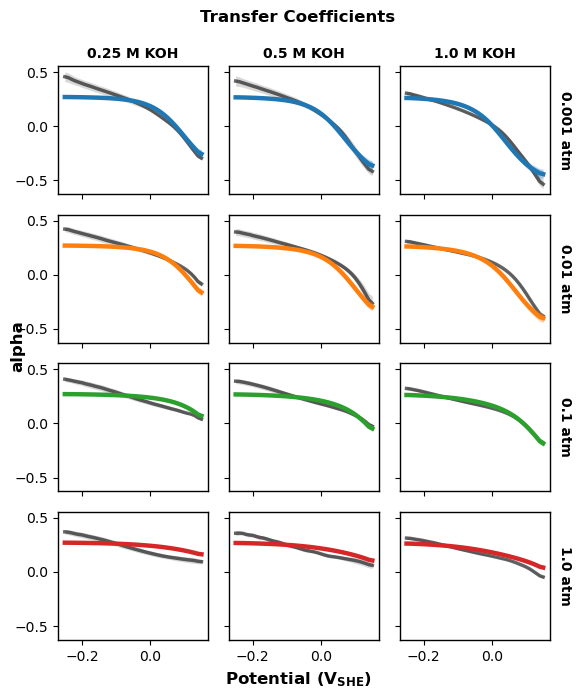

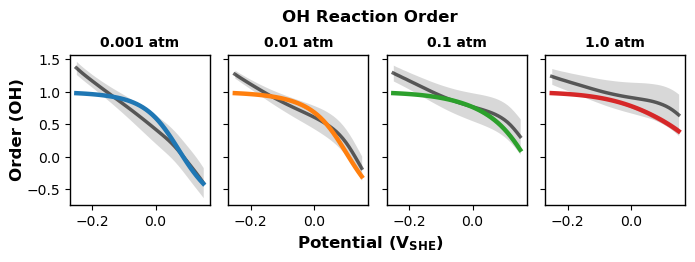

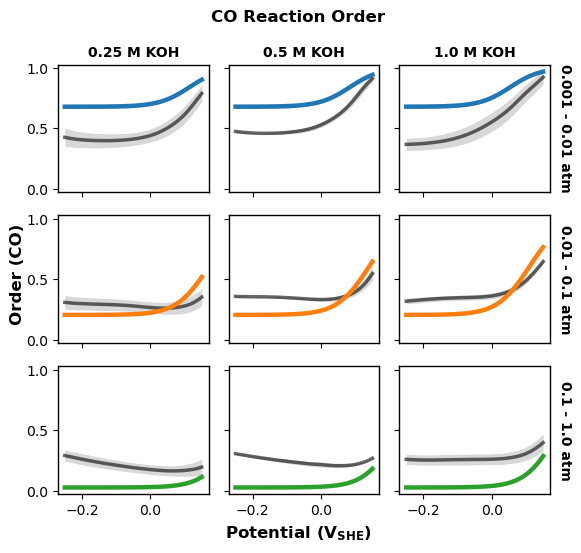

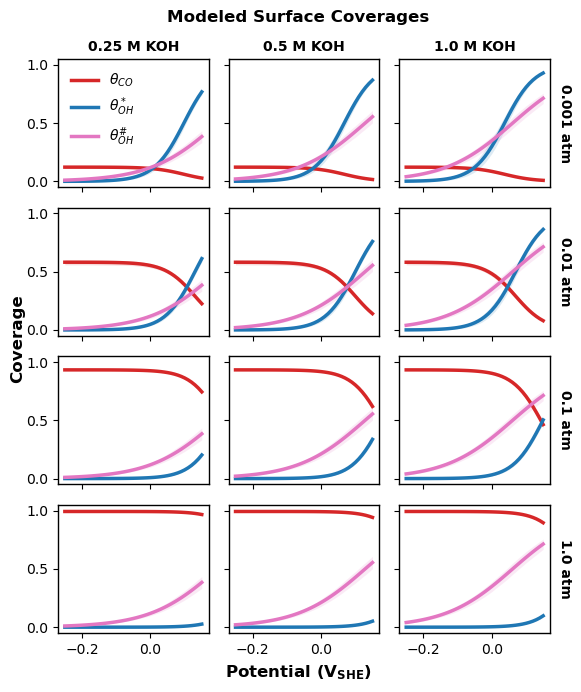

In [38]:
ppc_BF_LH_PCT_Ag_Pd = plot_posteriors(trace_BF_LH_PCT_Ag_Pd, BF_LH_PCT_Ag_Pd)
plot_model_fits(trace_BF_LH_PCT_Ag_Pd, ppc_BF_LH_PCT_Ag_Pd); plot_coverages(trace_BF_LH_PCT_Ag_Pd)

# Comparison

                 rank    elpd_loo      p_loo  elpd_diff        weight         se        dse  warning scale
BF_LH_PCT_Ag_Pd     0  543.196587   9.352331   0.000000  7.304177e-01  56.911618   0.000000    False   log
BF_ER_LH            1  481.715877  11.660219  61.480709  2.695823e-01  56.669142  16.786337    False   log
BF_PCT_Ag           2  476.780384   9.459344  66.416202  4.074185e-11  55.245796  10.403111    False   log


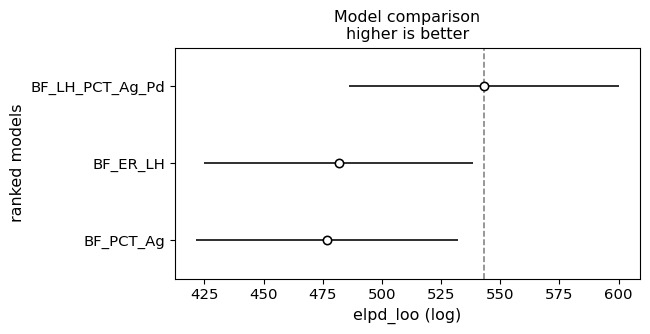

In [42]:
comparison_dict = {
    # "LH": loo_LH, # Low ELPD - bad fits
    # "BF": loo_BF, # Low ELPD - bad fits
    # "ER": loo_ER, # Moderate ELPD
    # "BF_ER": loo_BF_ER, # Should be equivalent to BF_PCT_Ag
    "BF_ER_LH": loo_BF_ER_LH, # Should be equivalent to BF_LH_PCT_Ag, but is not. 
    "BF_PCT_Ag": loo_BF_PCT_Ag, # Good model! 
    # "BF_LH_PCT_Ag": loo_BF_LH_PCT_Ag, # LH DRC too low. 
    # "BF_ER_PCT_Ag": loo_BF_ER_PCT_Ag, # ER has low DRCs. 
    # "BF_LH_ER_PCT_Ag": loo_BF_LH_ER_PCT_Ag, # Both LH and ER have low DRCs. 
    # "CO_BF_PCT_Ag": loo_CO_BF_PCT_Ag, # CO adsorption DRC is negligible. 
    # "OH_Ag_BF_PCT_Ag": loo_OH_Ag_BF_PCT_Ag, # High ELPD, but unphysical. Very low CO binding energy. Suggests OH ads on Ag has high DRCs. 
    "BF_LH_PCT_Ag_Pd": loo_BF_LH_PCT_Ag_Pd # Minimal ELPD increase - LH has low DRCs. 
}

comp_df = az.compare(comparison_dict, ic="loo", method="stacking")
print(comp_df)
az.plot_compare(comp_df, insample_dev=False)
plt.show()